In [ ]:
主实验 使用多个随机种子

In [ ]:
Entropy: {'auroc': 0.6483933657229017, 'prr': 0.3815520446222122}
SemanticEntropy: {'auroc': 0.6476796783380802, 'prr': 0.3817748340535589}
MARS: {'auroc': 0.6403853241749036, 'prr': 0.25004691695443415}
LARS: {'auroc': 0.5826101524543474, 'prr': 0.11998820589573395}
SentSAR: {'auroc': 0.6407187133523202, 'prr': 0.3189377757991942}
TokenSAR: {'auroc': 0.6365890433908528, 'prr': 0.3661800406334507}
Confidence: {'auroc': 0.6349790584687552, 'prr': 0.36465069833780245}
Inside: {'auroc': 0.5936890601440777, 'prr': 0.15551997927986438}
AttentionScore: {'auroc': 0.4860914726084771, 'prr': -0.035257024229759994}
EccentricityUncertainty: {'auroc': 0.5916066342770985, 'prr': 0.1438465037441849}
EccentricityConfidence: {'auroc': 0.5925933992293517, 'prr': 0.15049412105357587}
MatrixDegreeConfidence: {'auroc': 0.4933891774166527, 'prr': -0.04051003303436451}
MatrixDegreeUncertainty: {'auroc': 0.5055855252136037, 'prr': -0.015018937276435612}
SumEigenUncertainty: {'auroc': 0.5060579661584855, 'prr': -0.014505404629913957}
PTrue: {'auroc': 0.6120706986094824, 'prr': 0.218298100547547}
VerbalizedConfidence: {'auroc': 0.5624811526218797, 'prr': 0.26941228944538265}
SelfDetection: {'auroc': 0.50031998659742, 'prr': 0.0016730700215816334}
DirectionalEntailmentGraph: {'auroc': 0.5883581839504105, 'prr': 0.06913171102167469}


========= PRR (mean ± std across seeds) =========
       model  prr_mean  prr_std
          LR    0.4784   0.0010
       MLP32    0.4715   0.0033
       MLP64    0.4703   0.0026
    MLP32x32    0.4646   0.0157
    MLP64x32    0.4632   0.0024
MLP128x64x32    0.4158   0.0380

🌱 Best single PRR -> Model: MLP32x32, Seed: 123, PRR=0.4820
📊 Best mean PRR   -> Model: LR, PRR_mean=0.4784 ± 0.0010


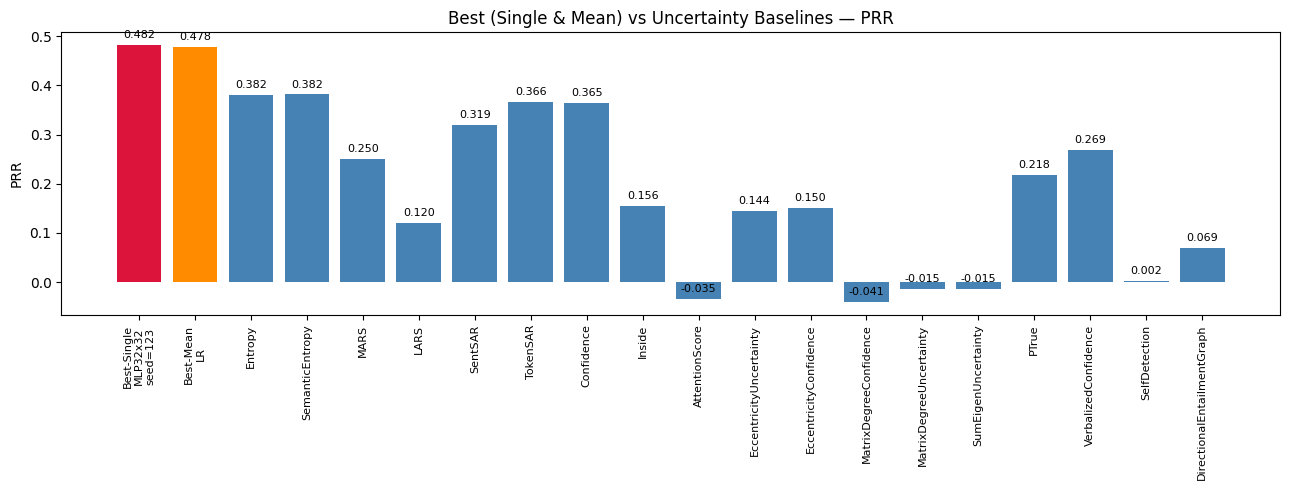

In [1]:
# -*- coding: utf-8 -*-
"""
Multi-seed comparison of LR & MLP architectures + uncertainty baselines (PRR-focused)
====================================================================================
•  Runs each trainable model under several random seeds, aggregates PRR (mean ± std).
•  Identifies the **single best PRR run** (model, seed) and the **mean-best model**.
•  Plots PRR bar chart:   Best-Single  |  Best-Mean  |  External baselines.
•  Data paths & baseline numbers stay *exactly* as provided by the user.
"""

# ───────────────────────── Imports & Config ──────────────────────────────
import json, math
from typing import Dict, List, Sequence, Any
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier

# ----- user-provided file paths (DON'T TOUCH) -----
TRAIN_TEST_FILE_PATH = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json"

# ----- model space & seeds -----
MLP_SPACE: Sequence[tuple] = [(32,), (64,), (32, 32), (64, 32), (128, 64, 32)]
RANDOM_SEEDS: Sequence[int] = [42, 7, 99, 123, 2025]
SPLIT_SEED: int = 42   # fixed split to keep test set constant
# ----- external baselines (unchanged) -----
BASELINES: Dict[str, Dict[str, float]] = {
    "Entropy": {"auroc": 0.6483933657229017, "prr": 0.3815520446222122},
    "SemanticEntropy": {"auroc": 0.6476796783380802, "prr": 0.3817748340535589},
    "MARS": {"auroc": 0.6403853241749036, "prr": 0.25004691695443415},
    "LARS": {"auroc": 0.5826101524543474, "prr": 0.11998820589573395},
    "SentSAR": {"auroc": 0.6407187133523202, "prr": 0.3189377757991942},
    "TokenSAR": {"auroc": 0.6365890433908528, "prr": 0.3661800406334507},
    "Confidence": {"auroc": 0.6349790584687552, "prr": 0.36465069833780245},
    "Inside": {"auroc": 0.5936890601440777, "prr": 0.15551997927986438},
    "AttentionScore": {"auroc": 0.4860914726084771, "prr": -0.035257024229759994},
    "EccentricityUncertainty": {"auroc": 0.5916066342770985, "prr": 0.1438465037441849},
    "EccentricityConfidence": {"auroc": 0.5925933992293517, "prr": 0.15049412105357587},
    "MatrixDegreeConfidence": {"auroc": 0.4933891774166527, "prr": -0.04051003303436451},
    "MatrixDegreeUncertainty": {"auroc": 0.5055855252136037, "prr": -0.015018937276435612},
    "SumEigenUncertainty": {"auroc": 0.5060579661584855, "prr": -0.014505404629913957},
    "PTrue": {"auroc": 0.6120706986094824, "prr": 0.218298100547547},
    "VerbalizedConfidence": {"auroc": 0.5624811526218797, "prr": 0.26941228944538265},
    "SelfDetection": {"auroc": 0.50031998659742, "prr": 0.0016730700215816334},
    "DirectionalEntailmentGraph": {"auroc": 0.5883581839504105, "prr": 0.06913171102167469},
}

# ───────────────────────── PRR utilities ────────────────────────────────

def _normalize(a: np.ndarray) -> np.ndarray:
    lo, hi = a.min(), a.max()
    return np.zeros_like(a) if math.isclose(lo, hi) else (a - lo) / (hi - lo)

def _prediction_rejection_curve(est, tgt):
    tgt = _normalize(tgt)
    order = np.argsort(est)[::-1]
    cum = np.cumsum(tgt[order])
    return (cum / np.arange(1, len(est) + 1)).mean()

def _random_prr(tgt, num_iter=1000, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(tgt))
    vals = [_prediction_rejection_curve(rng.permutation(idx), tgt) for _ in range(num_iter)]
    return float(np.mean(vals))

def calc_prr(y_true: np.ndarray, y_score: np.ndarray, seed=0) -> float:
    ue = _prediction_rejection_curve(y_score, y_true)
    orc = _prediction_rejection_curve(y_true, y_true)
    rnd = _random_prr(y_true, seed=seed)
    denom = orc - rnd
    return 0.0 if math.isclose(denom, 0) else (ue - rnd) / denom

# ───────────────────────── Core training loop ───────────────────────────

def load_data(path: str):
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)
    X = np.array([it["normalized_truth_values"] for it in d])
    y = np.array([it["label"] for it in d])
    return X, y


def train_eval_multi_seed(X_tr, y_tr, X_te, y_te, seeds=RANDOM_SEEDS):
    """Return per-model list of PRR across seeds + best single record."""
    prr_records: Dict[str, List[float]] = {}
    best_single = {"model": None, "seed": None, "prr": -float("inf")}

    for seed in seeds:
        # ----- Logistic Regression -----
        lr = LogisticRegression(max_iter=1000, random_state=seed).fit(X_tr, y_tr)
        prr_lr = calc_prr(y_te, lr.predict_proba(X_te)[:, 1], seed)
        prr_records.setdefault("LR", []).append(prr_lr)
        if prr_lr > best_single["prr"]:
            best_single.update({"model": "LR", "seed": seed, "prr": prr_lr})

        # ----- MLPs -----
        for hid in MLP_SPACE:
            name = "MLP" + "x".join(map(str, hid))
            mlp = MLPClassifier(hidden_layer_sizes=hid, max_iter=1000, random_state=seed).fit(X_tr, y_tr)
            prr_mlp = calc_prr(y_te, mlp.predict_proba(X_te)[:, 1], seed)
            prr_records.setdefault(name, []).append(prr_mlp)
            if prr_mlp > best_single["prr"]:
                best_single.update({"model": name, "seed": seed, "prr": prr_mlp})

    return prr_records, best_single

# ───────────────────────── Aggregation & Plot ───────────────────────────

def aggregate(prr_dict: Dict[str, List[float]]):
    return pd.DataFrame([
        {"model": m, "prr_mean": float(np.mean(vals)), "prr_std": float(np.std(vals, ddof=0))}
        for m, vals in prr_dict.items()
    ])


def plot_prr(best_single: Dict[str, Any], best_mean: Dict[str, Any]):
    labels = [
        f"Best-Single\n{best_single['model']}\nseed={best_single['seed']}",
        f"Best-Mean\n{best_mean['model']}",
    ] + list(BASELINES.keys())

    prr_vals = [best_single["prr"], best_mean["prr_mean"]] + [v["prr"] for v in BASELINES.values()]
    colors = ["crimson", "darkorange"] + ["steelblue"] * len(BASELINES)

    plt.figure(figsize=(13, 5))
    bars = plt.bar(labels, prr_vals, color=colors)
    plt.ylabel("PRR")
    plt.title("Best (Single & Mean) vs Uncertainty Baselines — PRR")
    plt.xticks(rotation=90, fontsize=8)
    for bar, val in zip(bars, prr_vals):
        plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

# ───────────────────────── Main ─────────────────────────────────────────

def main():
    # 1) data split (fixed)
    X, y = load_data(TRAIN_TEST_FILE_PATH)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SPLIT_SEED, stratify=y)

    # 2) multi-seed training/eval
    prr_dict, best_single = train_eval_multi_seed(X_tr, y_tr, X_te, y_te)
    df = aggregate(prr_dict)

    # 3) mean-best model
    best_mean_row = df.loc[df["prr_mean"].idxmax()]
    best_mean = best_mean_row.to_dict()

    # 4) console summary
    pd.set_option("display.float_format", lambda x: f"{x:.4f}")
    print("\n========= PRR (mean ± std across seeds) =========")
    print(df.to_string(index=False))
    print(f"\n🌱 Best single PRR -> Model: {best_single['model']}, Seed: {best_single['seed']}, PRR={best_single['prr']:.4f}")
    print(f"📊 Best mean PRR   -> Model: {best_mean['model']}, PRR_mean={best_mean['prr_mean']:.4f} ± {best_mean['prr_std']:.4f}")

    # 5) visualization
    plot_prr(best_single, best_mean)


if __name__ == "__main__":
    main()



========= Model Performance (mean ± std across seeds) =========
       model  prr_mean  prr_std  auroc_mean  auroc_std
          LR    0.4784   0.0010      0.6828     0.0000
       MLP32    0.4715   0.0033      0.6811     0.0016
       MLP64    0.4703   0.0026      0.6813     0.0016
    MLP32x32    0.4646   0.0157      0.6793     0.0053
    MLP64x32    0.4632   0.0024      0.6795     0.0035
MLP128x64x32    0.4158   0.0380      0.6675     0.0140

========================= BEST MODELS =========================
🌱 Best single PRR -> Model: MLP32x32, Seed: 123, PRR=0.4820
📊 Best mean PRR   -> Model: LR, PRR_mean=0.4784 ± 0.0010
-----------------------------------------------------------------
🚀 Best single AUROC -> Model: MLP64x32, Seed: 2025, AUROC=0.6864
📈 Best mean AUROC   -> Model: LR, AUROC_mean=0.6828 ± 0.0000


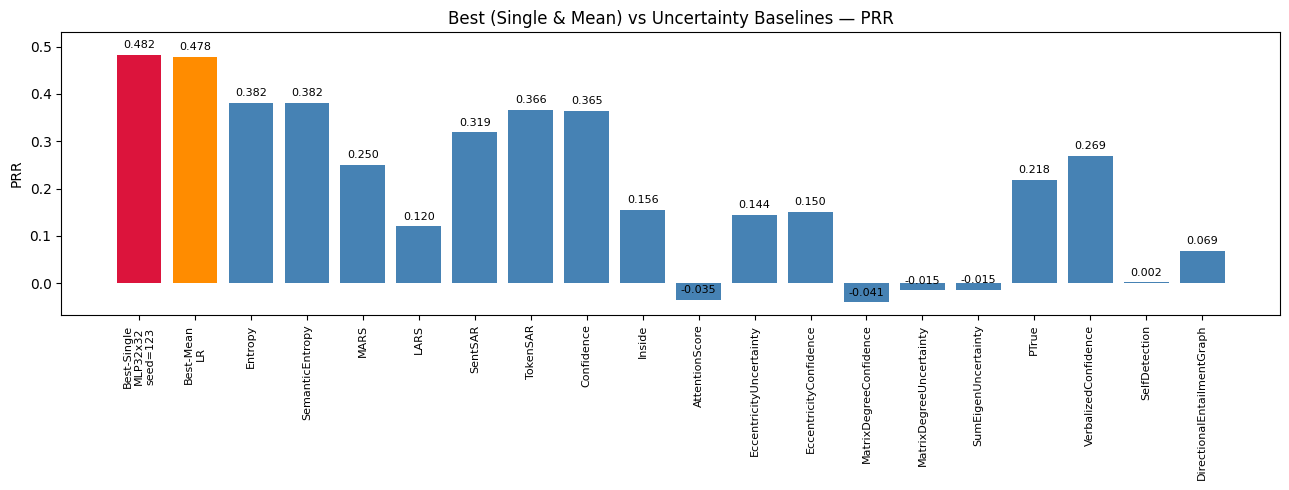

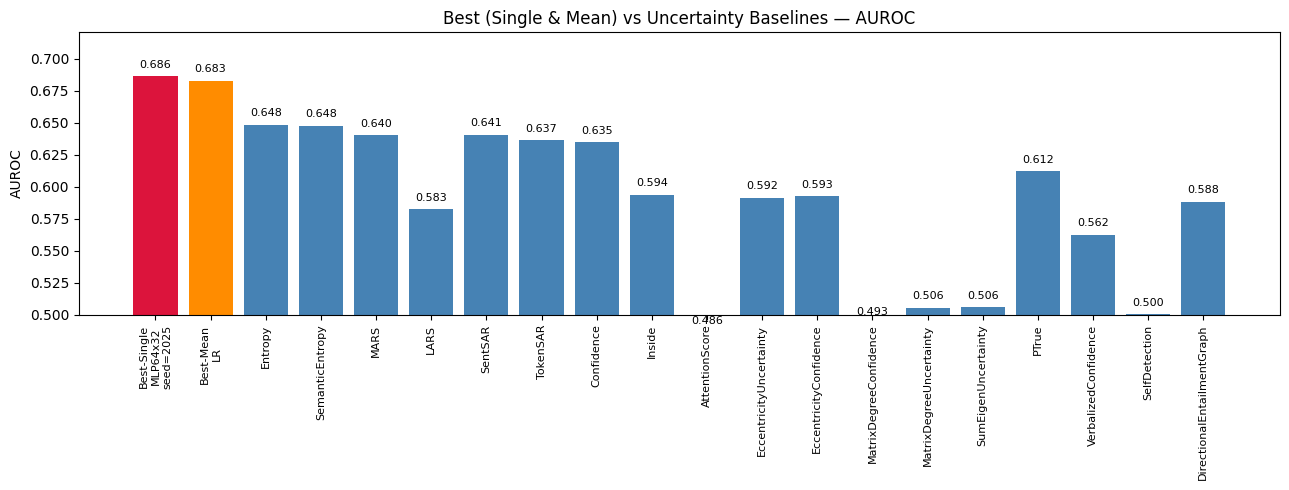

In [2]:
# -*- coding: utf-8 -*-
"""
Multi-seed comparison of LR & MLP architectures + uncertainty baselines (PRR & AUROC)
====================================================================================
•  Runs each trainable model under several random seeds, aggregates PRR & AUROC (mean ± std).
•  Identifies the best single run (model, seed) and the mean-best model for each metric.
•  Plots bar charts for PRR and AUROC: Best-Single | Best-Mean | External baselines.
•  Data paths & baseline numbers stay *exactly* as provided by the user.
"""

# ───────────────────────── Imports & Config ──────────────────────────────
import json, math
from typing import Dict, List, Sequence, Any
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score  # <-- 新增：导入AUROC计算函数

# ----- user-provided file paths (DON'T TOUCH) -----
TRAIN_TEST_FILE_PATH = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json"

# ----- model space & seeds -----
MLP_SPACE: Sequence[tuple] = [(32,), (64,), (32, 32), (64, 32), (128, 64, 32)]
RANDOM_SEEDS: Sequence[int] = [42, 7, 99, 123, 2025]
SPLIT_SEED: int = 42   # fixed split to keep test set constant
# ----- external baselines (unchanged) -----
BASELINES: Dict[str, Dict[str, float]] = {
    "Entropy": {"auroc": 0.6483933657229017, "prr": 0.3815520446222122},
    "SemanticEntropy": {"auroc": 0.6476796783380802, "prr": 0.3817748340535589},
    "MARS": {"auroc": 0.6403853241749036, "prr": 0.25004691695443415},
    "LARS": {"auroc": 0.5826101524543474, "prr": 0.11998820589573395},
    "SentSAR": {"auroc": 0.6407187133523202, "prr": 0.3189377757991942},
    "TokenSAR": {"auroc": 0.6365890433908528, "prr": 0.3661800406334507},
    "Confidence": {"auroc": 0.6349790584687552, "prr": 0.36465069833780245},
    "Inside": {"auroc": 0.5936890601440777, "prr": 0.15551997927986438},
    "AttentionScore": {"auroc": 0.4860914726084771, "prr": -0.035257024229759994},
    "EccentricityUncertainty": {"auroc": 0.5916066342770985, "prr": 0.1438465037441849},
    "EccentricityConfidence": {"auroc": 0.5925933992293517, "prr": 0.15049412105357587},
    "MatrixDegreeConfidence": {"auroc": 0.4933891774166527, "prr": -0.04051003303436451},
    "MatrixDegreeUncertainty": {"auroc": 0.5055855252136037, "prr": -0.015018937276435612},
    "SumEigenUncertainty": {"auroc": 0.5060579661584855, "prr": -0.014505404629913957},
    "PTrue": {"auroc": 0.6120706986094824, "prr": 0.218298100547547},
    "VerbalizedConfidence": {"auroc": 0.5624811526218797, "prr": 0.26941228944538265},
    "SelfDetection": {"auroc": 0.50031998659742, "prr": 0.0016730700215816334},
    "DirectionalEntailmentGraph": {"auroc": 0.5883581839504105, "prr": 0.06913171102167469},
}

# ───────────────────────── PRR utilities ────────────────────────────────

def _normalize(a: np.ndarray) -> np.ndarray:
    lo, hi = a.min(), a.max()
    return np.zeros_like(a) if math.isclose(lo, hi) else (a - lo) / (hi - lo)

def _prediction_rejection_curve(est, tgt):
    tgt = _normalize(tgt)
    order = np.argsort(est)[::-1]
    cum = np.cumsum(tgt[order])
    return (cum / np.arange(1, len(est) + 1)).mean()

def _random_prr(tgt, num_iter=1000, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(tgt))
    vals = [_prediction_rejection_curve(rng.permutation(idx), tgt) for _ in range(num_iter)]
    return float(np.mean(vals))

def calc_prr(y_true: np.ndarray, y_score: np.ndarray, seed=0) -> float:
    ue = _prediction_rejection_curve(y_score, y_true)
    orc = _prediction_rejection_curve(y_true, y_true)
    rnd = _random_prr(y_true, seed=seed)
    denom = orc - rnd
    return 0.0 if math.isclose(denom, 0) else (ue - rnd) / denom

# ───────────────────────── Core training loop ───────────────────────────

def load_data(path: str):
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)
    X = np.array([it["normalized_truth_values"] for it in d])
    y = np.array([it["label"] for it in d])
    return X, y


def train_eval_multi_seed(X_tr, y_tr, X_te, y_te, seeds=RANDOM_SEEDS):
    """Return per-model lists of PRR & AUROC across seeds + best single run records."""
    prr_records: Dict[str, List[float]] = {}
    auroc_records: Dict[str, List[float]] = {}  # <-- 新增: 存储 AUROC 分数
    best_single_prr = {"model": None, "seed": None, "prr": -float("inf")}
    best_single_auroc = {"model": None, "seed": None, "auroc": -float("inf")} # <-- 新增: 追踪最佳 AUROC

    for seed in seeds:
        # ----- Logistic Regression -----
        lr = LogisticRegression(max_iter=1000, random_state=seed).fit(X_tr, y_tr)
        y_pred_proba_lr = lr.predict_proba(X_te)[:, 1]

        # 计算 PRR 和 AUROC
        prr_lr = calc_prr(y_te, y_pred_proba_lr, seed)
        auroc_lr = roc_auc_score(y_te, y_pred_proba_lr) # <-- 新增

        prr_records.setdefault("LR", []).append(prr_lr)
        auroc_records.setdefault("LR", []).append(auroc_lr) # <-- 新增

        # 更新最佳单次记录
        if prr_lr > best_single_prr["prr"]:
            best_single_prr.update({"model": "LR", "seed": seed, "prr": prr_lr})
        if auroc_lr > best_single_auroc["auroc"]: # <-- 新增
            best_single_auroc.update({"model": "LR", "seed": seed, "auroc": auroc_lr})

        # ----- MLPs -----
        for hid in MLP_SPACE:
            name = "MLP" + "x".join(map(str, hid))
            mlp = MLPClassifier(hidden_layer_sizes=hid, max_iter=1000, random_state=seed).fit(X_tr, y_tr)
            y_pred_proba_mlp = mlp.predict_proba(X_te)[:, 1]

            # 计算 PRR 和 AUROC
            prr_mlp = calc_prr(y_te, y_pred_proba_mlp, seed)
            auroc_mlp = roc_auc_score(y_te, y_pred_proba_mlp) # <-- 新增

            prr_records.setdefault(name, []).append(prr_mlp)
            auroc_records.setdefault(name, []).append(auroc_mlp) # <-- 新增

            # 更新最佳单次记录
            if prr_mlp > best_single_prr["prr"]:
                best_single_prr.update({"model": name, "seed": seed, "prr": prr_mlp})
            if auroc_mlp > best_single_auroc["auroc"]: # <-- 新增
                best_single_auroc.update({"model": name, "seed": seed, "auroc": auroc_mlp})

    return prr_records, auroc_records, best_single_prr, best_single_auroc

# ───────────────────────── Aggregation & Plot ───────────────────────────

# v-- 函数已更新，可同时处理 PRR 和 AUROC --v
def aggregate(prr_dict: Dict[str, List[float]], auroc_dict: Dict[str, List[float]]):
    """Aggregates PRR and AUROC scores into a single DataFrame."""
    records = []
    for m, prr_vals in prr_dict.items():
        auroc_vals = auroc_dict[m]
        records.append({
            "model": m,
            "prr_mean": float(np.mean(prr_vals)),
            "prr_std": float(np.std(prr_vals, ddof=0)),
            "auroc_mean": float(np.mean(auroc_vals)), # <-- 新增
            "auroc_std": float(np.std(auroc_vals, ddof=0))  # <-- 新增
        })
    return pd.DataFrame(records)


def plot_prr(best_single: Dict[str, Any], best_mean: Dict[str, Any]):
    labels = [
        f"Best-Single\n{best_single['model']}\nseed={best_single['seed']}",
        f"Best-Mean\n{best_mean['model']}",
    ] + list(BASELINES.keys())

    prr_vals = [best_single["prr"], best_mean["prr_mean"]] + [v["prr"] for v in BASELINES.values()]
    colors = ["crimson", "darkorange"] + ["steelblue"] * len(BASELINES)

    plt.figure(figsize=(13, 5))
    bars = plt.bar(labels, prr_vals, color=colors)
    plt.ylabel("PRR")
    plt.title("Best (Single & Mean) vs Uncertainty Baselines — PRR")
    plt.xticks(rotation=90, fontsize=8)
    plt.ylim(top=max(prr_vals) * 1.1)
    for bar, val in zip(bars, prr_vals):
        plt.text(bar.get_x() + bar.get_width() / 2, val + 0.01, f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()

# <-- 新增: AUROC 可视化函数 -->
def plot_auroc(best_single: Dict[str, Any], best_mean: Dict[str, Any]):
    labels = [
        f"Best-Single\n{best_single['model']}\nseed={best_single['seed']}",
        f"Best-Mean\n{best_mean['model']}",
    ] + list(BASELINES.keys())

    auroc_vals = [best_single["auroc"], best_mean["auroc_mean"]] + [v["auroc"] for v in BASELINES.values()]
    colors = ["crimson", "darkorange"] + ["steelblue"] * len(BASELINES)

    plt.figure(figsize=(13, 5))
    bars = plt.bar(labels, auroc_vals, color=colors)
    plt.ylabel("AUROC")
    plt.title("Best (Single & Mean) vs Uncertainty Baselines — AUROC")
    plt.xticks(rotation=90, fontsize=8)
    # AUROC 的理论下界是 0.5 (随机猜测)
    plt.ylim(bottom=0.5, top=max(auroc_vals) * 1.05)
    for bar, val in zip(bars, auroc_vals):
        plt.text(bar.get_x() + bar.get_width() / 2, val + 0.005, f"{val:.3f}", ha="center", va="bottom", fontsize=8)
    plt.tight_layout()
    plt.show()


# ───────────────────────── Main ─────────────────────────────────────────

def main():
    # 1) data split (fixed)
    X, y = load_data(TRAIN_TEST_FILE_PATH)
    X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, random_state=SPLIT_SEED, stratify=y)

    # 2) multi-seed training/eval (现在返回4个值)
    prr_dict, auroc_dict, best_single_prr, best_single_auroc = train_eval_multi_seed(X_tr, y_tr, X_te, y_te)
    df = aggregate(prr_dict, auroc_dict)

    # 3) mean-best models (分别为 PRR 和 AUROC 找到最佳)
    best_mean_prr_row = df.loc[df["prr_mean"].idxmax()]
    best_mean_prr = best_mean_prr_row.to_dict()
    best_mean_auroc_row = df.loc[df["auroc_mean"].idxmax()] # <-- 新增
    best_mean_auroc = best_mean_auroc_row.to_dict()       # <-- 新增

    # 4) console summary (更新输出内容)
    pd.set_option("display.float_format", lambda x: f"{x:.4f}")
    print("\n========= Model Performance (mean ± std across seeds) =========")
    print(df.sort_values("prr_mean", ascending=False).to_string(index=False))

    print("\n" + "="*25 + " BEST MODELS " + "="*25)
    print(f"🌱 Best single PRR -> Model: {best_single_prr['model']}, Seed: {best_single_prr['seed']}, PRR={best_single_prr['prr']:.4f}")
    print(f"📊 Best mean PRR   -> Model: {best_mean_prr['model']}, PRR_mean={best_mean_prr['prr_mean']:.4f} ± {best_mean_prr['prr_std']:.4f}")
    print("-" * 65)
    print(f"🚀 Best single AUROC -> Model: {best_single_auroc['model']}, Seed: {best_single_auroc['seed']}, AUROC={best_single_auroc['auroc']:.4f}")
    print(f"📈 Best mean AUROC   -> Model: {best_mean_auroc['model']}, AUROC_mean={best_mean_auroc['auroc_mean']:.4f} ± {best_mean_auroc['auroc_std']:.4f}")
    print("="*65)

    # 5) visualization
    plot_prr(best_single_prr, best_mean_prr)
    plot_auroc(best_single_auroc, best_mean_auroc) # <-- 新增: 显示 AUROC 图表


if __name__ == "__main__":
    main()

In [ ]:
逐一移除方法的敏感性分析 (Sensitivity Analysis of Removing Methods One by One)

In [2]:
import json
import copy
import os

# 原始数据路径（不改它）
in_path = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json"

# 输出目录（确保存在）
out_dir = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/pruned_variants"
os.makedirs(out_dir, exist_ok=True)

# 读取原始
with open(in_path, "r", encoding="utf-8") as f:
    original_data = json.load(f)

# 找出 method 数量（取第一个合法 entry）
n_methods = None
for entry in original_data:
    vals = entry.get("normalized_truth_values")
    if isinstance(vals, list):
        n_methods = len(vals)
        break
if n_methods is None:
    raise ValueError("没有找到任何含 normalized_truth_values 的 entry。")

print(f"Detected {n_methods} methods (indices 0..{n_methods-1}).")

def prune_one_method(original, remove_idx):
    pruned = copy.deepcopy(original)
    for entry in pruned:
        vals = entry.get("normalized_truth_values")
        if not isinstance(vals, list):
            continue
        if remove_idx >= len(vals):
            raise ValueError(f"Entry has too few normalized_truth_values for removing index {remove_idx}")
        entry["normalized_truth_values"] = [v for i, v in enumerate(vals) if i != remove_idx]
    return pruned

# 针对每个 method_i 单独删除并保存
for i in range(n_methods):
    out_path = os.path.join(out_dir, f"pruned_no_method_{i}.json")
    pruned_data = prune_one_method(original_data, i)
    with open(out_path, "w", encoding="utf-8") as f:
        json.dump(pruned_data, f, ensure_ascii=False, indent=2)

    # 验证第一条样本的对齐（简单 spot check）
    orig_vals = original_data[0].get("normalized_truth_values", [])
    pruned_vals = pruned_data[0].get("normalized_truth_values", [])
    # prefix should be same up to remove_idx-1
    if i > 0:
        assert orig_vals[i-1] == pruned_vals[i-1], f"前缀对齐出错 method_{i}"
    # the value that was originally at i+1 should now be at i (if exists)
    if i + 1 < len(orig_vals):
        assert orig_vals[i+1] == pruned_vals[i], f"后缀对齐出错 method_{i}"
    print(f"[done] removed method_{i}, saved to {out_path} (len before {len(orig_vals)}, after {len(pruned_vals)})")


Detected 18 methods (indices 0..17).
[done] removed method_0, saved to /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/pruned_variants/pruned_no_method_0.json (len before 18, after 17)
[done] removed method_1, saved to /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/pruned_variants/pruned_no_method_1.json (len before 18, after 17)
[done] removed method_2, saved to /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/pruned_variants/pruned_no_method_2.json (len before 18, after 17)
[done] removed method_3, saved to /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/pruned_variants/pruned_no_method_3.json (len before 18, after 17)
[done] removed method_4, saved to /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/pruned_variants/pruned_no_method_4.json (len before 18, after 17)
[done] removed method_5, saved to /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/pruned_variants/pruned_no_method_5.json (len before 18, after 17)
[done] removed method


--- Evaluating variant with removed Original ---
           model  auroc    prr
0             LR 0.6828 0.4776
1         MLP-32 0.6794 0.4699
2         MLP-64 0.6797 0.4676
3      MLP-32x32 0.6812 0.4736
4      MLP-64x32 0.6774 0.4600
5  MLP-128x64x32 0.6619 0.3935
Best AUROC (removed Original): LR = 0.6828
Best PRR   (removed Original): LR = 0.4776

--- Evaluating variant with removed method_0 ---
           model  auroc    prr
0             LR 0.6827 0.4773
1         MLP-32 0.6840 0.4734
2         MLP-64 0.6825 0.4742
3      MLP-32x32 0.6849 0.4757
4      MLP-64x32 0.6762 0.4400
5  MLP-128x64x32 0.6838 0.4686
Best AUROC (removed method_0): MLP-32x32 = 0.6849
Best PRR   (removed method_0): LR = 0.4773

--- Evaluating variant with removed method_1 ---
           model  auroc    prr
0             LR 0.6831 0.4773
1         MLP-32 0.6854 0.4746
2         MLP-64 0.6838 0.4753
3      MLP-32x32 0.6814 0.4662
4      MLP-64x32 0.6720 0.4404
5  MLP-128x64x32 0.6633 0.3614
Best AUROC (removed 

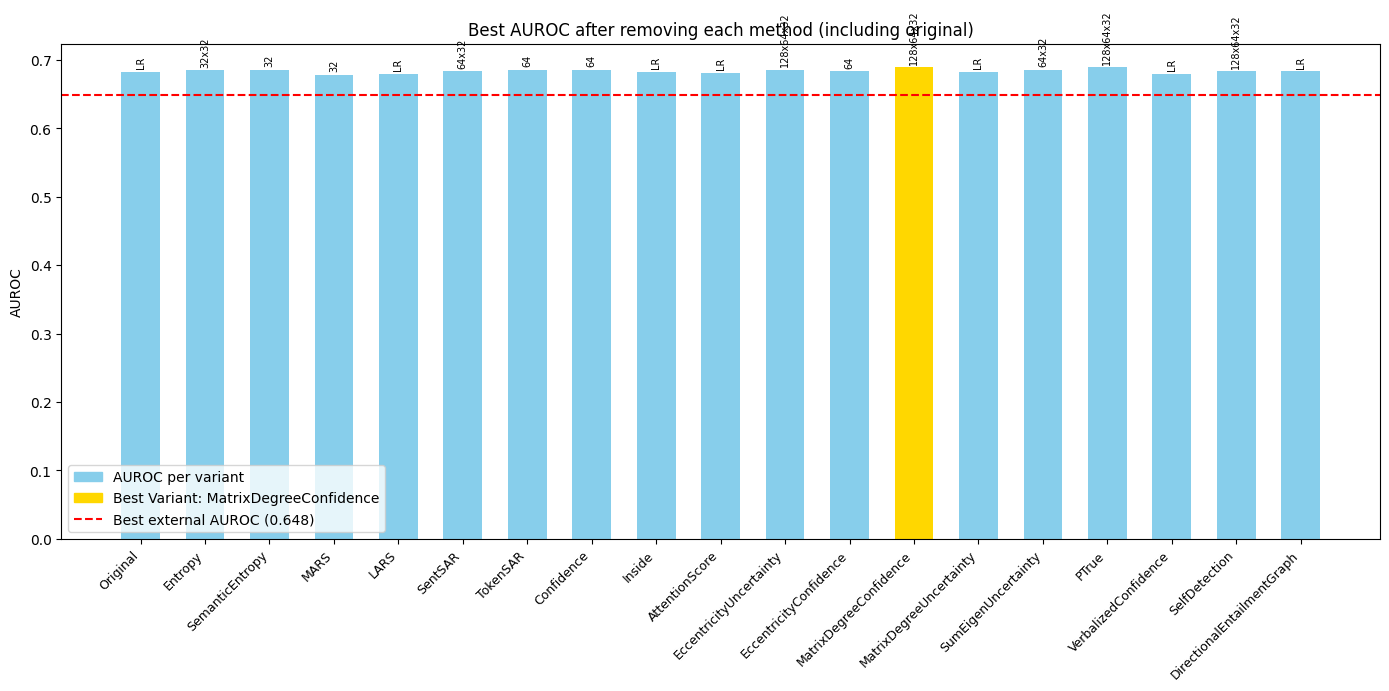

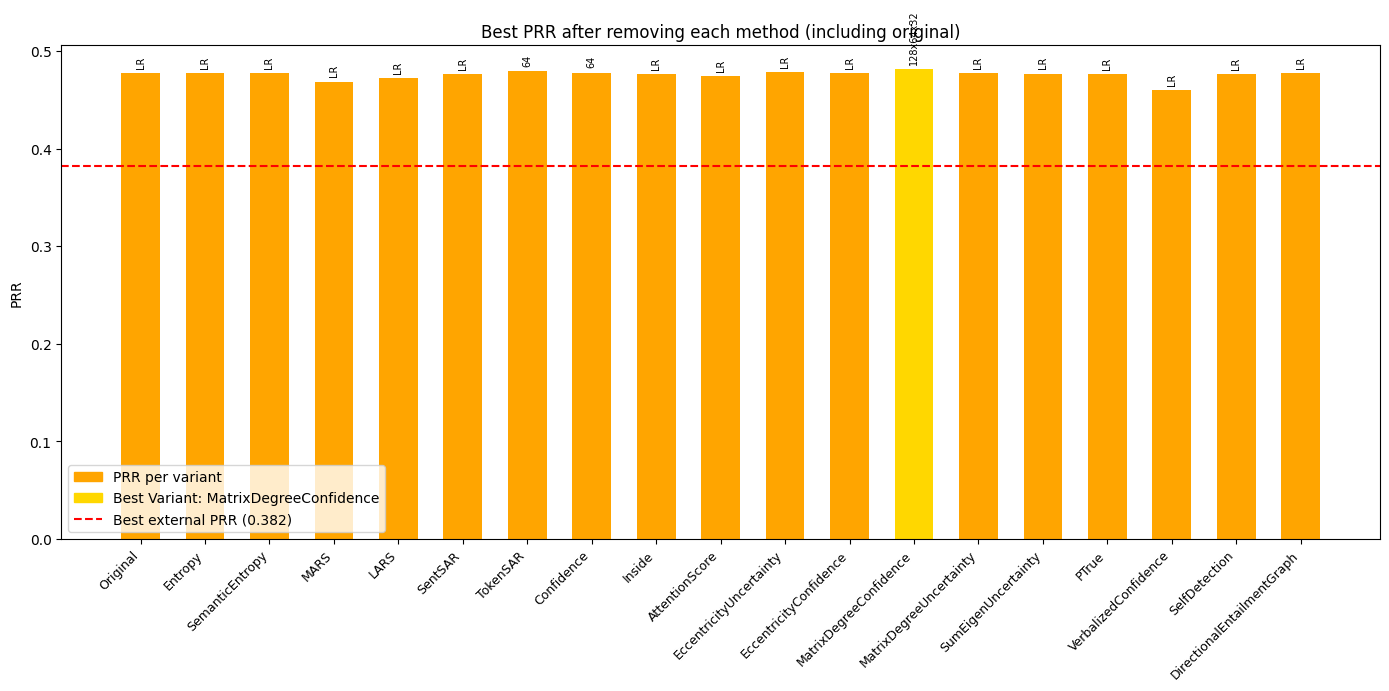

In [3]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
针对每个去掉一个 method 的 variant（pruned_no_method_{i}.json）+ 原始（什么都不去掉）：
训练 LR + 多个 MLP，计算 AUROC/PRR，汇总“删掉哪个 method 后的 best AUROC/PRR”，
并画两张条形图（各 variant 最佳 AUROC / PRR），不输出 CSV。
显示时用具体名称（baseline 顺序映射），模型名做简写防止溢出。
[MODIFIED] 在图中标出最佳表现的条形。
"""

import json
import math
import os
from typing import List, Tuple, Dict, Any
from glob import glob

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches # 导入用于自定义图例
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score

# ───────────────────────── 配置 ────────────────────────────────────────
PRUNED_DIR = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/pruned_variants"
ORIGINAL_FILE = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json"
MLP_ARCHITECTURES = [(32,), (64,), (32, 32), (64, 32), (128, 64, 32)]
METRICS_TO_CALCULATE = ["auroc", "prr"]
RANDOM_SEED = 42

# external baselines (顺序固定，用于 mapping removed_method -> display name)
EXTERNAL_BASELINES = {
    "Entropy": {"auroc": 0.6483933657229017, "prr": 0.3815520446222122},
    "SemanticEntropy": {"auroc": 0.6476796783380802, "prr": 0.3817748340535589},
    "MARS": {"auroc": 0.6403853241749036, "prr": 0.25004691695443415},
    "LARS": {"auroc": 0.5826101524543474, "prr": 0.11998820589573395},
    "SentSAR": {"auroc": 0.6407187133523202, "prr": 0.3189377757991942},
    "TokenSAR": {"auroc": 0.6365890433908528, "prr": 0.3661800406334507},
    "Confidence": {"auroc": 0.6349790584687552, "prr": 0.36465069833780245},
    "Inside": {"auroc": 0.5936890601440777, "prr": 0.15551997927986438},
    "AttentionScore": {"auroc": 0.4860914726084771, "prr": -0.035257024229759994},
    "EccentricityUncertainty": {"auroc": 0.5916066342770985, "prr": 0.1438465037441849},
    "EccentricityConfidence": {"auroc": 0.5925933992293517, "prr": 0.15049412105357587},
    "MatrixDegreeConfidence": {"auroc": 0.4933891774166527, "prr": -0.04051003303436451},
    "MatrixDegreeUncertainty": {"auroc": 0.5055855252136037, "prr": -0.015018937276435612},
    "SumEigenUncertainty": {"auroc": 0.5060579661584855, "prr": -0.014505404629913957},
    "PTrue": {"auroc": 0.6120706986094824, "prr": 0.218298100547547},
    "VerbalizedConfidence": {"auroc": 0.5624811526218797, "prr": 0.26941228944538265},
    "SelfDetection": {"auroc": 0.50031998659742, "prr": 0.0016730700215816334},
    "DirectionalEntailmentGraph": {"auroc": 0.5883581839504105, "prr": 0.06913171102167469},
}
BASELINE_METHOD_NAMES = list(EXTERNAL_BASELINES.keys())

# ───────────────────────── 工具函数 ───────────────────────────────────
def normalize(arr: np.ndarray) -> np.ndarray:
    a = np.asarray(arr)
    lo, hi = a.min(), a.max()
    if math.isclose(lo, hi):
        return np.zeros_like(a)
    return (a - lo) / (hi - lo)

def prediction_rejection_curve(estimator: np.ndarray, target: np.ndarray) -> float:
    target = normalize(target)
    ue = np.asarray(estimator)
    order = np.argsort(ue)[::-1]
    cum_sum = np.cumsum(target[order])
    return (cum_sum / np.arange(1, len(ue) + 1)).mean()

def get_random_scores(func, metrics: np.ndarray, num_iter: int = 1000, seed: int = 42) -> float:
    rng = np.random.default_rng(seed)
    idx = np.arange(len(metrics))
    vals = [func(rng.permutation(idx), metrics) for _ in range(num_iter)]
    return np.mean(vals)

def calculate_metrics(metric_names: List[str], y_true: np.ndarray, y_score: np.ndarray, seed: int = 0) -> Dict[str, float]:
    out: Dict[str, float] = {}
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    if "auroc" in metric_names:
        try:
            out["auroc"] = roc_auc_score(y_true, y_score)
        except ValueError:
            out["auroc"] = 0.5

    if "prr" in metric_names:
        ue_prr = prediction_rejection_curve(y_score, y_true)
        orc_prr = prediction_rejection_curve(y_true, y_true)
        rnd_prr = get_random_scores(prediction_rejection_curve, y_true, seed=seed)
        denominator = orc_prr - rnd_prr
        if math.isclose(denominator, 0):
            out["prr"] = 0.0
        else:
            out["prr"] = (ue_prr - rnd_prr) / denominator

    return out

def load_data(file_path: str) -> Tuple[np.ndarray, np.ndarray]:
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    X = np.array([item["normalized_truth_values"] for item in data])
    y = np.array([item["label"] for item in data])
    return X, y

def train_and_evaluate_models(
    X_tr: np.ndarray, y_tr: np.ndarray, X_te: np.ndarray, y_te: np.ndarray
) -> List[Dict[str, Any]]:
    results: List[Dict[str, Any]] = []

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED).fit(X_tr, y_tr)
    lr_scores = lr.predict_proba(X_te)[:, 1]
    results.append({
        "model": "LR",
        **calculate_metrics(METRICS_TO_CALCULATE, y_te, lr_scores, seed=RANDOM_SEED)
    })

    # MLPs
    for hidden_layers in MLP_ARCHITECTURES:
        mlp = MLPClassifier(hidden_layer_sizes=hidden_layers, max_iter=1000, random_state=RANDOM_SEED)
        mlp.fit(X_tr, y_tr)
        mlp_scores = mlp.predict_proba(X_te)[:, 1]
        model_name = "MLP-" + "x".join(map(str, hidden_layers))
        results.append({
            "model": model_name,
            **calculate_metrics(METRICS_TO_CALCULATE, y_te, mlp_scores, seed=RANDOM_SEED)
        })
    return results

def abbreviate_model(name: str, max_len: int = 8) -> str:
    if name.startswith("MLP-"):
        core = name[len("MLP-"):]
    else:
        core = name
    if len(core) <= max_len:
        return core
    return core[: max_len - 1] + "…"

# ───────────────────────── 主流程 ─────────────────────────────────────
def main():
    # collect pruned variants + original
    pattern = os.path.join(PRUNED_DIR, "pruned_no_method_*.json")
    pruned_paths = sorted(glob(pattern))
    if not pruned_paths:
        raise FileNotFoundError(f"No pruned files found in {PRUNED_DIR} matching pattern.")

    # prepare list of (filepath, removed_method_tag)
    variants: List[Tuple[str, str]] = []
    # original (nothing removed)
    variants.append((ORIGINAL_FILE, "none"))
    for fp in pruned_paths:
        basename = os.path.basename(fp)
        removed_method = basename.replace("pruned_no_", "").replace(".json", "")  # e.g. method_5
        variants.append((fp, removed_method))

    variant_summaries: List[Dict[str, Any]] = []

    best_external_auroc = max(v["auroc"] for v in EXTERNAL_BASELINES.values())
    best_external_prr = max(v["prr"] for v in EXTERNAL_BASELINES.values())

    for fp, removed_method in variants:
        label_for_print = "Original" if removed_method == "none" else removed_method
        print(f"\n--- Evaluating variant with removed {label_for_print} ---")
        X, y = load_data(fp)
        X_tr, X_te, y_tr, y_te = train_test_split(
            X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
        )
        model_results = train_and_evaluate_models(X_tr, y_tr, X_te, y_te)
        

        # put into DataFrame to pick best
        import pandas as pd
        df_variant = pd.DataFrame(model_results)
        best_auroc_row = df_variant.loc[df_variant["auroc"].idxmax()]
        best_prr_row = df_variant.loc[df_variant["prr"].idxmax()]
        print(df_variant)

        variant_summaries.append({
            "removed_method": removed_method,
            "best_auroc": best_auroc_row["auroc"],
            "best_auroc_model": best_auroc_row["model"],
            "best_prr": best_prr_row["prr"],
            "best_prr_model": best_prr_row["model"],
        })

        print(f"Best AUROC (removed {label_for_print}): {best_auroc_row['model']} = {best_auroc_row['auroc']:.4f}")
        print(f"Best PRR   (removed {label_for_print}): {best_prr_row['model']} = {best_prr_row['prr']:.4f}")

    # summary frame
    import pandas as pd
    summary_df = pd.DataFrame(variant_summaries)
    # derive display_method
    def get_display(method_tag: str):
        if method_tag == "none":
            return "Original"
        idx = int(method_tag.split("_")[1])
        if 0 <= idx < len(BASELINE_METHOD_NAMES):
            return BASELINE_METHOD_NAMES[idx]
        return method_tag

    summary_df["display_method"] = summary_df["removed_method"].apply(get_display)
    # for ordering, put original first, then by baseline order
    def sort_key(row):
        if row["removed_method"] == "none":
            return -1
        idx = int(row["removed_method"].split("_")[1])
        return idx

    summary_df["sorter"] = summary_df.apply(sort_key, axis=1)
    summary_df.sort_values("sorter", inplace=True)
    summary_df.reset_index(drop=True, inplace=True)

    x = np.arange(len(summary_df))

    # === [MODIFIED] AUROC plot with highlighting ===
    plt.figure(figsize=(14, 7))

    best_auroc_idx = summary_df['best_auroc'].idxmax()
    best_auroc_name = summary_df.loc[best_auroc_idx, 'display_method']
    auroc_colors = ['gold' if i == best_auroc_idx else 'skyblue' for i in range(len(summary_df))]
    
    plt.bar(x, summary_df["best_auroc"], width=0.6, color=auroc_colors)
    plt.axhline(best_external_auroc, color="red", linestyle="--")
    
    # Custom legend
    auroc_legend_handles = [
        mpatches.Patch(color='skyblue', label='AUROC per variant'),
        mpatches.Patch(color='gold', label=f'Best Variant: {best_auroc_name}'),
        plt.Line2D([0], [0], color='red', linestyle='--', label=f'Best external AUROC ({best_external_auroc:.3f})')
    ]
    plt.legend(handles=auroc_legend_handles)

    plt.xticks(x, summary_df["display_method"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("AUROC")
    plt.title("Best AUROC after removing each method (including original)") 
    for idx, row in summary_df.iterrows():
        short_name = abbreviate_model(row["best_auroc_model"], max_len=10)
        plt.text(idx, row["best_auroc"] + 0.005, short_name, ha="center", va="bottom", fontsize=7, rotation=90)
    plt.tight_layout()
    plt.show()

    # === [MODIFIED] PRR plot with highlighting ===
    plt.figure(figsize=(14, 7))

    best_prr_idx = summary_df['best_prr'].idxmax()
    best_prr_name = summary_df.loc[best_prr_idx, 'display_method']
    prr_colors = ['gold' if i == best_prr_idx else 'orange' for i in range(len(summary_df))]

    plt.bar(x, summary_df["best_prr"], width=0.6, color=prr_colors)
    plt.axhline(best_external_prr, color="red", linestyle="--")

    # Custom legend
    prr_legend_handles = [
        mpatches.Patch(color='orange', label='PRR per variant'),
        mpatches.Patch(color='gold', label=f'Best Variant: {best_prr_name}'),
        plt.Line2D([0], [0], color='red', linestyle='--', label=f'Best external PRR ({best_external_prr:.3f})')
    ]
    plt.legend(handles=prr_legend_handles)

    plt.xticks(x, summary_df["display_method"], rotation=45, ha="right", fontsize=9)
    plt.ylabel("PRR")
    plt.title("Best PRR after removing each method (including original)")
    for idx, row in summary_df.iterrows():
        short_name = abbreviate_model(row["best_prr_model"], max_len=10)
        plt.text(idx, row["best_prr"] + 0.005, short_name, ha="center", va="bottom", fontsize=7, rotation=90)
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()

In [ ]:
(in-deep analyse) 副实验一_分析校准前后不同模型的能力变化

Loading main dataset…
Split done: train 2578, test 1105
Training baseline Logistic Regression …

---------- Logistic Regression Weights ----------
Intercept (Bias): -2.5930
Feature Weights:
  - Weight for Feature 1: 0.3279
  - Weight for Feature 2: 0.6280
  - Weight for Feature 3: 0.8328
  - Weight for Feature 4: 0.9557
  - Weight for Feature 5: 0.0698
  - Weight for Feature 6: 1.0011
  - Weight for Feature 7: 0.0058
  - Weight for Feature 8: 0.1705
  - Weight for Feature 9: -0.9396
  - Weight for Feature 10: 0.6302
  - Weight for Feature 11: -0.1008
  - Weight for Feature 12: -0.6868
  - Weight for Feature 13: -0.2686
  - Weight for Feature 14: -0.1934
  - Weight for Feature 15: 0.6390
  - Weight for Feature 16: 1.2892
  - Weight for Feature 17: 1.0190
  - Weight for Feature 18: -0.3174
---------------------------------------------

Training MLP(32,) …

Training MLP(64,) …

Training MLP(32, 32) …

Training MLP(64, 32) …

Training MLP(128, 64, 32) …

================ Evaluation Results

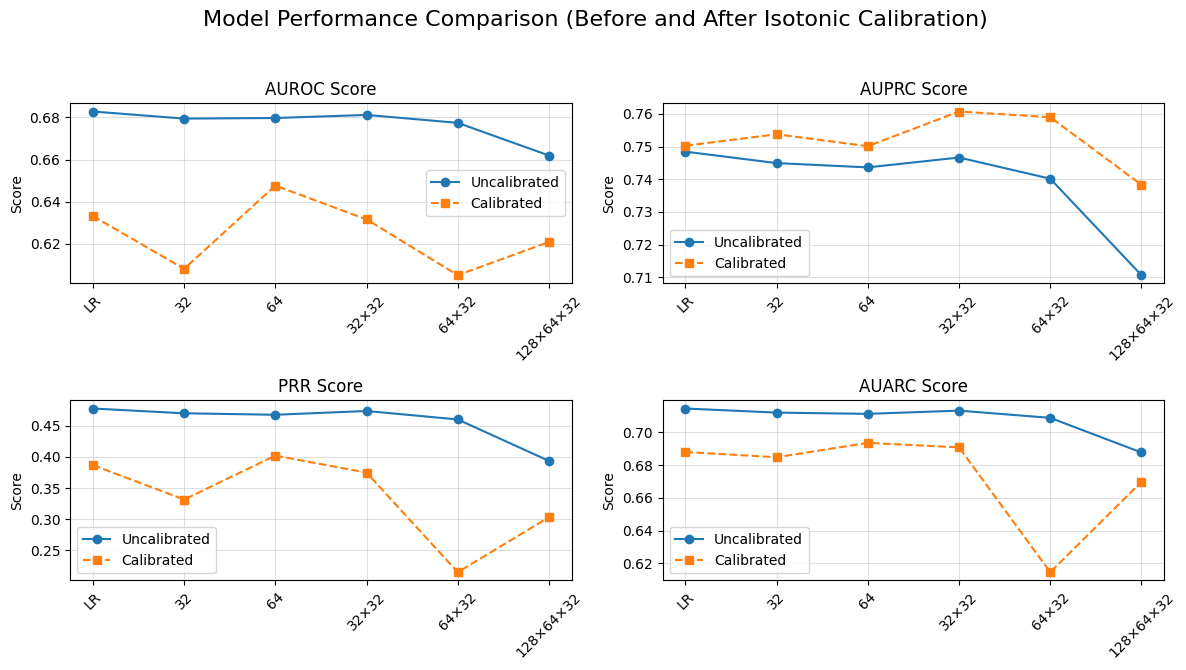

In [4]:
# -*- coding: utf-8 -*-
"""
集成等渗回归校准功能，对 LR 和多种 MLP 模型生成的真值分数进行校准和评估，
并可视化不同隐藏层结构对指标的影响（英文标注版）。

步骤：
1. 加载主数据集，并分割为训练集和测试集，同时保存测试集原始索引。
2. 加载独立的校准数据集。
3. 训练对照模型 LR，以及若干不同结构的 MLP。
4. 为每个模型拟合 IsotonicRegression 校准器。
5. 在测试集上生成未校准和校准后的分数，并计算四项指标。
6. 汇总所有模型结果到 DataFrame，打印并可视化（英文标签）。

⚠️ 请根据实际文件路径调整 TRAIN_TEST_FILE_PATH 与 CALIBRATION_FILE_PATH。
"""

# 1. Imports ────────────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.isotonic import IsotonicRegression as _Iso  # 官方实现

# ======================================================================
# 2. 校准器与评估函数
# ======================================================================
class IsoCalibrator:
    """轻量封装 sklearn.isotonic.IsotonicRegression，用于概率校准。"""
    def __init__(self, y_min: float = 0.0, y_max: float = 1.0):
        self._iso = _Iso(y_min=y_min, y_max=y_max, out_of_bounds="clip")

    def fit(self, scores, y_true):
        """scores: 原始模型输出（概率/分数）   y_true: 0/1 标签"""
        assert len(scores) == len(y_true), "scores 与 y_true 长度不匹配"
        self._iso.fit(scores, y_true)

    def __call__(self, scores):
        """向量化预测：接收标量或 ndarray，返回校准后概率"""
        scores = np.asarray(scores, dtype=float)
        return self._iso.predict(scores)

# ----------------------------------------------------------------------
def area_under_accuracy_coverage_curve(t_s, acc):
    df = pd.DataFrame({"t_s": t_s, "acc": acc}).sort_values("t_s", ascending=False)
    df["acc_mean"] = df["acc"].expanding().mean()
    return auc(np.linspace(0, 1, len(df)), df["acc_mean"])

def normalize(target):
    min_t, max_t = np.min(target), np.max(target)
    if np.isclose(min_t, max_t):
        min_t -= 1
        max_t += 1
    return (np.array(target) - min_t) / (max_t - min_t)

def prediction_rejection_curve(estimator, target):
    target = normalize(target)
    ue = np.array(estimator)
    num_obs = len(ue)
    ue_argsort = np.argsort(ue)[::-1]
    sorted_metrics = np.array(target)[ue_argsort]
    cumsum = np.cumsum(sorted_metrics)
    scores = cumsum / np.arange(1, num_obs + 1)
    return np.sum(scores) / num_obs

def get_random_scores(function, metrics, num_iter=1000, seed=42):
    np.random.seed(seed)
    rand_scores_template = np.arange(len(metrics))
    value = []
    for _ in range(num_iter):
        np.random.shuffle(rand_scores_template)
        rand_val = function(rand_scores_template, metrics)
        value.append(rand_val)
    return np.mean(value)

def metric_score(metric_names, y_true, y_score, seed=0):
    """计算四项指标：PRR、AUROC、AUPRC、AUARC"""
    eval_dict = {}
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    if "prr" in metric_names:
        ue_prr = prediction_rejection_curve(y_score, y_true)
        orc_prr = prediction_rejection_curve(y_true, y_true)
        rand_prr = get_random_scores(prediction_rejection_curve, y_true, seed=seed)
        eval_dict["prr"] = 0.0 if np.isclose(orc_prr, rand_prr) else (ue_prr - rand_prr) / (orc_prr - rand_prr)

    if "auroc" in metric_names:
        try:
            eval_dict["auroc"] = roc_auc_score(y_true, y_score)
        except ValueError:  # 若标签只有单类
            eval_dict["auroc"] = 0.5

    if "auprc" in metric_names:
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        eval_dict["auprc"] = auc(recall, precision)

    if "auarc" in metric_names:
        eval_dict["auarc"] = area_under_accuracy_coverage_curve(y_score, y_true)

    return eval_dict

# ======================================================================
# 3. 主执行流程
# ======================================================================
def main():
    # --- 配置 ------------------------------------------------------------
    TRAIN_TEST_FILE_PATH = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json'
    CALIBRATION_FILE_PATH = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_for_calibrating_qwen.json'

    MLP_SPACE = [
        (32,), (64,), (32, 32), (64, 32), (128, 64, 32)
    ]
    METRICS_TO_CALCULATE = ["prr", "auroc", "auprc", "auarc"]

    # --- 1. 加载主数据集 --------------------------------------------------
    print("Loading main dataset…")
    with open(TRAIN_TEST_FILE_PATH, 'r', encoding='utf-8') as f:
        all_data = json.load(f)
    X = np.array([item['normalized_truth_values'] for item in all_data])
    y = np.array([item['label'] for item in all_data])
    indices = np.arange(len(X))

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, indices, test_size=0.3, random_state=42, stratify=y
    )
    print(f"Split done: train {len(X_train)}, test {len(X_test)}")

    # with open("test_indices_3.json", "w", encoding='utf-8') as f:
    #     json.dump(idx_test.tolist(), f)
    # print("Test indices saved to test_indices_3.json\n")

    # --- 2. 基线 LR -------------------------------------------------------
    print("Training baseline Logistic Regression …")
    lr_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)

    lr_weights = lr_model.coef_[0] 
    lr_intercept = lr_model.intercept_[0] 
    print("\n---------- Logistic Regression Weights ----------")
    print(f"Intercept (Bias): {lr_intercept:.4f}")
    print("Feature Weights:")
    for i, weight in enumerate(lr_weights):
        print(f"  - Weight for Feature {i+1}: {weight:.4f}")
    print("---------------------------------------------")

    # --- 3. 加载校准集 & 为 LR 拟合校准器 --------------------------------
    with open(CALIBRATION_FILE_PATH, 'r', encoding='utf-8') as f:
        calib_data = json.load(f)
    X_calib = np.array([item['normalized_truth_values'] for item in calib_data])
    y_calib = np.array([item['label'] for item in calib_data])

    lr_calibrator = IsoCalibrator()
    lr_scores_calib = lr_model.predict_proba(X_calib)[:, 1]
    lr_calibrator.fit(lr_scores_calib, y_calib)

    # --- 4. 遍历 MLP 结构 -------------------------------------------------
    results = []
    for hid in MLP_SPACE:
        print(f"\nTraining MLP{hid} …")
        mlp = MLPClassifier(hidden_layer_sizes=hid, max_iter=1000, random_state=42).fit(X_train, y_train)

        # 校准
        mlp_cal = IsoCalibrator()
        mlp_scores_calib = mlp.predict_proba(X_calib)[:, 1]
        mlp_cal.fit(mlp_scores_calib, y_calib)

        # 测试集
        mlp_scores_test = mlp.predict_proba(X_test)[:, 1]
        mlp_scores_test_cal = mlp_cal(mlp_scores_test)

        # 指标
        met_uncal = metric_score(METRICS_TO_CALCULATE, y_test, mlp_scores_test)
        met_cal   = metric_score(METRICS_TO_CALCULATE, y_test, mlp_scores_test_cal)

        results.append({
            "arch": "×".join(map(str, hid)),
            **{f"{m}_uncal": met_uncal[m] for m in METRICS_TO_CALCULATE},
            **{f"{m}_cal":   met_cal[m]   for m in METRICS_TO_CALCULATE},
        })

    # --- 5. LR 指标 -------------------------------------------------------
    lr_scores_test = lr_model.predict_proba(X_test)[:, 1]
    lr_scores_test_cal = lr_calibrator(lr_scores_test)
    lr_uncal_metrics = metric_score(METRICS_TO_CALCULATE, y_test, lr_scores_test)
    lr_cal_metrics   = metric_score(METRICS_TO_CALCULATE, y_test, lr_scores_test_cal)

    results.append({
        "arch": "LR",
        **{f"{m}_uncal": lr_uncal_metrics[m] for m in METRICS_TO_CALCULATE},
        **{f"{m}_cal":   lr_cal_metrics[m]   for m in METRICS_TO_CALCULATE},
    })

    # --- 6. 输出 & 可视化 --------------------------------------------------
    df = pd.DataFrame(results)
    plot_order = ['LR'] + ["×".join(map(str, hid)) for hid in MLP_SPACE]
    df['arch'] = pd.Categorical(df['arch'], categories=plot_order, ordered=True)
    df = df.sort_values('arch')

    print("\n================ Evaluation Results ================")
    print(df.round(4).to_string(index=False))

    # 可选：保存 CSV
    # df.to_csv("mlp_lr_results.csv", index=False)

    plt.figure(figsize=(12, 7))
    metrics_to_plot = ["auroc", "auprc", "prr", "auarc"]
    for i, metric in enumerate(metrics_to_plot):
        ax = plt.subplot(2, 2, i + 1)
        ax.plot(df["arch"], df[f"{metric}_uncal"], marker="o", label="Uncalibrated")
        ax.plot(df["arch"], df[f"{metric}_cal"], marker="s", linestyle="--", label="Calibrated")
        ax.set_title(f"{metric.upper()} Score")
        ax.set_ylabel("Score")
        ax.grid(alpha=.4)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle("Model Performance Comparison (Before and After Isotonic Calibration)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# -------------------------------------------------------------------------
if __name__ == "__main__":
    main()


加入保存图像

Loading main dataset…
Split done: train 2578, test 1105
Training baseline Logistic Regression …

---------- Logistic Regression Weights ----------
Intercept (Bias): -2.5930
Feature Weights:
  - Weight for Feature 1: 0.3279
  - Weight for Feature 2: 0.6280
  - Weight for Feature 3: 0.8328
  - Weight for Feature 4: 0.9557
  - Weight for Feature 5: 0.0698
  - Weight for Feature 6: 1.0011
  - Weight for Feature 7: 0.0058
  - Weight for Feature 8: 0.1705
  - Weight for Feature 9: -0.9396
  - Weight for Feature 10: 0.6302
  - Weight for Feature 11: -0.1008
  - Weight for Feature 12: -0.6868
  - Weight for Feature 13: -0.2686
  - Weight for Feature 14: -0.1934
  - Weight for Feature 15: 0.6390
  - Weight for Feature 16: 1.2892
  - Weight for Feature 17: 1.0190
  - Weight for Feature 18: -0.3174
---------------------------------------------

Training MLP(32,) …

Training MLP(64,) …

Training MLP(32, 32) …

Training MLP(64, 32) …

Training MLP(128, 64, 32) …

================ Evaluation Results

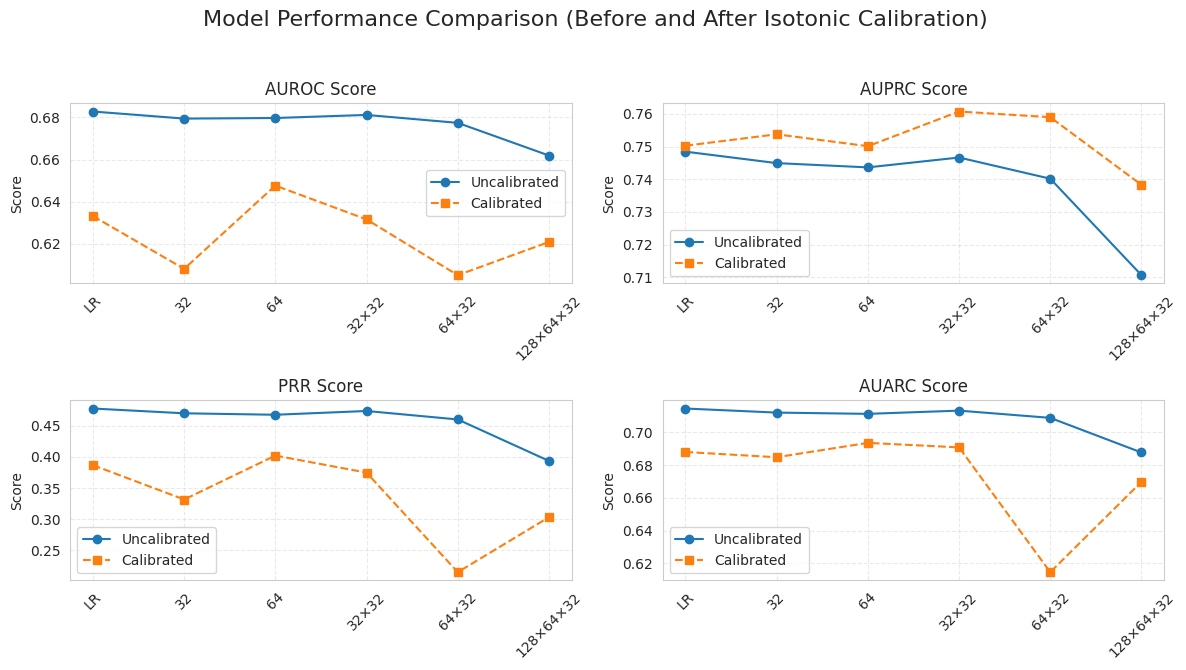

In [2]:
# -*- coding: utf-8 -*-
"""
集成等渗回归校准功能，对 LR 和多种 MLP 模型生成的真值分数进行校准和评估，
并可视化不同隐藏层结构对指标的影响（英文标注版）。

步骤：
1. 加载主数据集，并分割为训练集和测试集，同时保存测试集原始索引。
2. 加载独立的校准数据集。
3. 训练对照模型 LR，以及若干不同结构的 MLP。
4. 为每个模型拟合 IsotonicRegression 校准器。
5. 在测试集上生成未校准和校准后的分数，并计算四项指标。
6. 汇总所有模型结果到 DataFrame，打印、可视化（英文标签）并保存图像。

⚠️ 请根据实际文件路径调整 TRAIN_TEST_FILE_PATH 与 CALIBRATION_FILE_PATH。
"""

# 1. Imports ────────────────────────────────────────────────────────────────
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc
from sklearn.isotonic import IsotonicRegression as _Iso

# ======================================================================
# 2. 校准器与评估函数
# ======================================================================
class IsoCalibrator:
    """轻量封装 sklearn.isotonic.IsotonicRegression，用于概率校准。"""
    def __init__(self, y_min: float = 0.0, y_max: float = 1.0):
        self._iso = _Iso(y_min=y_min, y_max=y_max, out_of_bounds="clip")

    def fit(self, scores, y_true):
        """scores: 原始模型输出（概率/分数）   y_true: 0/1 标签"""
        assert len(scores) == len(y_true), "scores 与 y_true 长度不匹配"
        self._iso.fit(scores, y_true)

    def __call__(self, scores):
        """向量化预测：接收标量或 ndarray，返回校准后概率"""
        scores = np.asarray(scores, dtype=float)
        return self._iso.predict(scores)

# ----------------------------------------------------------------------
def area_under_accuracy_coverage_curve(t_s, acc):
    df = pd.DataFrame({"t_s": t_s, "acc": acc}).sort_values("t_s", ascending=False)
    df["acc_mean"] = df["acc"].expanding().mean()
    return auc(np.linspace(0, 1, len(df)), df["acc_mean"])

def normalize(target):
    min_t, max_t = np.min(target), np.max(target)
    if np.isclose(min_t, max_t):
        min_t -= 1
        max_t += 1
    return (np.array(target) - min_t) / (max_t - min_t)

def prediction_rejection_curve(estimator, target):
    target = normalize(target)
    ue = np.array(estimator)
    num_obs = len(ue)
    ue_argsort = np.argsort(ue)[::-1]
    sorted_metrics = np.array(target)[ue_argsort]
    cumsum = np.cumsum(sorted_metrics)
    scores = cumsum / np.arange(1, num_obs + 1)
    return np.sum(scores) / num_obs

def get_random_scores(function, metrics, num_iter=1000, seed=42):
    np.random.seed(seed)
    rand_scores_template = np.arange(len(metrics))
    value = []
    for _ in range(num_iter):
        np.random.shuffle(rand_scores_template)
        rand_val = function(rand_scores_template, metrics)
        value.append(rand_val)
    return np.mean(value)

def metric_score(metric_names, y_true, y_score, seed=0):
    """计算四项指标：PRR、AUROC、AUPRC、AUARC"""
    eval_dict = {}
    y_true = np.array(y_true)
    y_score = np.array(y_score)

    if "prr" in metric_names:
        ue_prr = prediction_rejection_curve(y_score, y_true)
        orc_prr = prediction_rejection_curve(y_true, y_true)
        rand_prr = get_random_scores(prediction_rejection_curve, y_true, seed=seed)
        eval_dict["prr"] = 0.0 if np.isclose(orc_prr, rand_prr) else (ue_prr - rand_prr) / (orc_prr - rand_prr)

    if "auroc" in metric_names:
        try:
            eval_dict["auroc"] = roc_auc_score(y_true, y_score)
        except ValueError:
            eval_dict["auroc"] = 0.5

    if "auprc" in metric_names:
        precision, recall, _ = precision_recall_curve(y_true, y_score)
        eval_dict["auprc"] = auc(recall, precision)

    if "auarc" in metric_names:
        eval_dict["auarc"] = area_under_accuracy_coverage_curve(y_score, y_true)

    return eval_dict

# ======================================================================
# 3. 主执行流程
# ======================================================================
def main():
    # --- 配置 ------------------------------------------------------------
    # ⚠️ 确保这些路径是正确的
    TRAIN_TEST_FILE_PATH = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json'
    CALIBRATION_FILE_PATH = '/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_for_calibrating_qwen.json'

    # 图像输出文件名（不含扩展名）
    OUTPUT_PLOT_FILENAME1 = "/home/qluai/zjs/TruthTorchLM-main/图片/校准/qwen_medmcqa_model_performance_comparison" # 建议根据数据源修改文件名
    OUTPUT_PLOT_FILENAME2 = "/home/qluai/zjs/TruthTorchLM-main/图片/PDF/calibrate/qwen_medmcqa_model_performance_comparison" # 建议根据数据源修改文件名

    MLP_SPACE = [
        (32,), (64,), (32, 32), (64, 32), (128, 64, 32)
    ]
    METRICS_TO_CALCULATE = ["prr", "auroc", "auprc", "auarc"]

    # --- 1. 加载主数据集 --------------------------------------------------
    print("Loading main dataset…")
    with open(TRAIN_TEST_FILE_PATH, 'r', encoding='utf-8') as f:
        all_data = json.load(f)
    X = np.array([item['normalized_truth_values'] for item in all_data])
    y = np.array([item['label'] for item in all_data])
    indices = np.arange(len(X))

    X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
        X, y, indices, test_size=0.3, random_state=42, stratify=y
    )
    print(f"Split done: train {len(X_train)}, test {len(X_test)}")

    # with open("test_indices_3.json", "w", encoding='utf-8') as f:
    #     json.dump(idx_test.tolist(), f)
    # print("Test indices saved to test_indices_3.json\n")

    # --- 2. 基线 LR -------------------------------------------------------
    print("Training baseline Logistic Regression …")
    lr_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_train, y_train)

    lr_weights = lr_model.coef_[0] 
    lr_intercept = lr_model.intercept_[0] 
    print("\n---------- Logistic Regression Weights ----------")
    print(f"Intercept (Bias): {lr_intercept:.4f}")
    print("Feature Weights:")
    for i, weight in enumerate(lr_weights):
        print(f"  - Weight for Feature {i+1}: {weight:.4f}")
    print("---------------------------------------------")

    # --- 3. 加载校准集 & 为 LR 拟合校准器 --------------------------------
    with open(CALIBRATION_FILE_PATH, 'r', encoding='utf-8') as f:
        calib_data = json.load(f)
    X_calib = np.array([item['normalized_truth_values'] for item in calib_data])
    y_calib = np.array([item['label'] for item in calib_data])

    lr_calibrator = IsoCalibrator()
    lr_scores_calib = lr_model.predict_proba(X_calib)[:, 1]
    lr_calibrator.fit(lr_scores_calib, y_calib)

    # --- 4. 遍历 MLP 结构 -------------------------------------------------
    results = []
    for hid in MLP_SPACE:
        print(f"\nTraining MLP{hid} …")
        mlp = MLPClassifier(hidden_layer_sizes=hid, max_iter=1000, random_state=42).fit(X_train, y_train)

        # 校准
        mlp_cal = IsoCalibrator()
        mlp_scores_calib = mlp.predict_proba(X_calib)[:, 1]
        mlp_cal.fit(mlp_scores_calib, y_calib)

        # 测试集
        mlp_scores_test = mlp.predict_proba(X_test)[:, 1]
        mlp_scores_test_cal = mlp_cal(mlp_scores_test)

        # 指标
        met_uncal = metric_score(METRICS_TO_CALCULATE, y_test, mlp_scores_test)
        met_cal   = metric_score(METRICS_TO_CALCULATE, y_test, mlp_scores_test_cal)

        results.append({
            "arch": "×".join(map(str, hid)),
            **{f"{m}_uncal": met_uncal[m] for m in METRICS_TO_CALCULATE},
            **{f"{m}_cal":   met_cal[m]   for m in METRICS_TO_CALCULATE},
        })

    # --- 5. LR 指标 -------------------------------------------------------
    lr_scores_test = lr_model.predict_proba(X_test)[:, 1]
    lr_scores_test_cal = lr_calibrator(lr_scores_test)
    lr_uncal_metrics = metric_score(METRICS_TO_CALCULATE, y_test, lr_scores_test)
    lr_cal_metrics   = metric_score(METRICS_TO_CALCULATE, y_test, lr_scores_test_cal)

    results.append({
        "arch": "LR",
        **{f"{m}_uncal": lr_uncal_metrics[m] for m in METRICS_TO_CALCULATE},
        **{f"{m}_cal":   lr_cal_metrics[m]   for m in METRICS_TO_CALCULATE},
    })

    # --- 6. 输出 & 可视化 --------------------------------------------------
    df = pd.DataFrame(results)
    plot_order = ['LR'] + ["×".join(map(str, hid)) for hid in MLP_SPACE]
    df['arch'] = pd.Categorical(df['arch'], categories=plot_order, ordered=True)
    df = df.sort_values('arch')

    print("\n================ Evaluation Results ================")
    print(df.round(4).to_string(index=False))

    # 可选：保存 CSV
    # df.to_csv("mlp_lr_results_qwen.csv", index=False) # 建议修改CSV文件名

    plt.figure(figsize=(12, 7))
    metrics_to_plot = ["auroc", "auprc", "prr", "auarc"]
    for i, metric in enumerate(metrics_to_plot):
        ax = plt.subplot(2, 2, i + 1)
        ax.plot(df["arch"], df[f"{metric}_uncal"], marker="o", label="Uncalibrated")
        ax.plot(df["arch"], df[f"{metric}_cal"], marker="s", linestyle="--", label="Calibrated")
        ax.set_title(f"{metric.upper()} Score")
        ax.set_ylabel("Score")
        ax.grid(alpha=.4)
        ax.legend()
        ax.tick_params(axis='x', rotation=45)

    plt.suptitle("Model Performance Comparison (Before and After Isotonic Calibration)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    # ======================================================
    # == 修改点：保存为 PNG 和 PDF ==
    # ======================================================
    try:
        # 保存为 PNG (设置高分辨率 dpi=300)
        plt.savefig(f"{OUTPUT_PLOT_FILENAME1}.png", dpi=300, bbox_inches='tight')
        # 保存为 PDF (矢量图)
        plt.savefig(f"{OUTPUT_PLOT_FILENAME2}.pdf", bbox_inches='tight')
        
        print(f"\n📈 Plot saved successfully to:")
        print(f"   - {OUTPUT_PLOT_FILENAME1}.png")
        print(f"   - {OUTPUT_PLOT_FILENAME2}.pdf")
        
    except Exception as e:
        print(f"\nError saving plot: {e}")
    # ======================================================

    plt.show() # 保留原始的显示功能

# -------------------------------------------------------------------------
if __name__ == "__main__":
    main()

In [ ]:
测试集正负样本数量

In [6]:
# -*- coding: utf-8 -*-
"""
Quick script: show basic statistics and preview of the **test‑set labels**
using exactly the same split strategy（30 % test, random_state=42, 按标签分层）。

1. 把 DATA_FILE 改成你的 JSON 路径。
2. 运行后会输出：
   · 测试集大小、正负样本数量
   · 一个 DataFrame (前 20 行) 包含 “原始索引 + 标签”
"""

import json
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

# ─── 1. 路径 ────────────────────────────────────────────────────────────
DATA_FILE = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json"   # ← 改成实际文件

# ─── 2. 载入标签 ─────────────────────────────────────────────────────────
with open(DATA_FILE, "r", encoding="utf-8") as f:
    data = json.load(f)

labels   = np.array([d["label"] for d in data])
indices  = np.arange(len(labels))              # 原始下标 0..N‑1

# ─── 3. 分层划分：30 % 作为 test，保持与主脚本一致 ─────────────────────
_, idx_test, _, y_test = train_test_split(
    indices,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

# ─── 4. 概览 ────────────────────────────────────────────────────────────
pos = int((y_test == 1).sum())
neg = int((y_test == 0).sum())
print(f"Test set size : {len(y_test)}")
print(f"  • Positives (1): {pos}")
print(f"  • Negatives (0): {neg}")

# 如果标签不止 0/1，可用 pandas.crosstab 查看分布
# print(pd.Series(y_test).value_counts())

# ─── 5. 明细 (前 20 行) ─────────────────────────────────────────────────
df_preview = pd.DataFrame({
    "orig_index": idx_test,
    "label": y_test
}).sort_values("orig_index").head(20)

print("\nFirst 20 rows of the test set:")
print(df_preview.to_string(index=False))


Test set size : 1105
  • Positives (1): 618
  • Negatives (0): 487

First 20 rows of the test set:
 orig_index  label
          1      1
          7      0
         10      1
         12      0
         15      1
         17      1
         18      1
         20      0
         25      1
         28      0
         29      0
         33      1
         35      1
         36      1
         39      1
         41      0
         42      0
         46      1
         47      1
         51      0


In [ ]:
下面这些需要等待meqa数据集的处理

In [ ]:
获取泛化实验的测试数据集

In [ ]:
Entropy: {'auroc': 0.6189044152808033, 'prr': 0.2536925451552571}
SemanticEntropy: {'auroc': 0.6182083842516338, 'prr': 0.2520014056102884}
MARS: {'auroc': 0.6210297008660539, 'prr': 0.21037039030341234}
LARS: {'auroc': 0.526422613038627, 'prr': 0.10078713976898536}
SentSAR: {'auroc': 0.5546782848945326, 'prr': 0.1668422622754884}
TokenSAR: {'auroc': 0.6242176292439297, 'prr': 0.2739017123748738}
Confidence: {'auroc': 0.6244301578024547, 'prr': 0.27260768335917224}
Inside: {'auroc': 0.5749907018755646, 'prr': 0.110003104391829}
AttentionScore: {'auroc': 0.4643961532330907, 'prr': -0.07553265478409232}
EccentricityUncertainty: {'auroc': 0.5692843100791669, 'prr': 0.08199265556187557}
EccentricityConfidence: {'auroc': 0.5796982094468944, 'prr': 0.22412293948380943}
MatrixDegreeConfidence: {'auroc': 0.5029275808936826, 'prr': 0.03574373938128873}
MatrixDegreeUncertainty: {'auroc': 0.5031188565963551, 'prr': 0.03744066936270847}
SumEigenUncertainty: {'auroc': 0.5031294830242814, 'prr': 0.03745174706977082}
PTrue: {'auroc': 0.6449604165559747, 'prr': 0.31739060908554445}
VerbalizedConfidence: {'auroc': 0.5969236491153498, 'prr': 0.22707433604131358}
SelfDetection: {'auroc': 0.5, 'prr': 0.1093989226677376}
DirectionalEntailmentGraph: {'auroc': 0.5473035439137135, 'prr': 0.005709780061758026}


✅ 测试数据集已成功保存至: medqa_test_dataset.json

---------- Logistic Regression Weights ----------
Intercept (Bias): -3.8567
   - Weight for Feature 1: -0.1670
   - Weight for Feature 2: 0.1355
   - Weight for Feature 3: 1.8160
   - Weight for Feature 4: 0.7020
   - Weight for Feature 5: 0.2309
   - Weight for Feature 6: 0.7088
   - Weight for Feature 7: 0.7829
   - Weight for Feature 8: -0.3752
   - Weight for Feature 9: 0.2460
   - Weight for Feature 10: 0.1444
   - Weight for Feature 11: -0.4922
   - Weight for Feature 12: -0.1038
   - Weight for Feature 13: -0.1420
   - Weight for Feature 14: -0.1411
   - Weight for Feature 15: 1.7105
   - Weight for Feature 16: 2.0385
   - Weight for Feature 17: -0.0742
   - Weight for Feature 18: 0.5513
---------------------------------------------

========= Summary (AUROC / PRR) - Uncalibrated & Baselines =========
                     model  auroc     prr
                        LR 0.6613  0.4058
             MLP-128x64x32 0.6562  0.3880
             

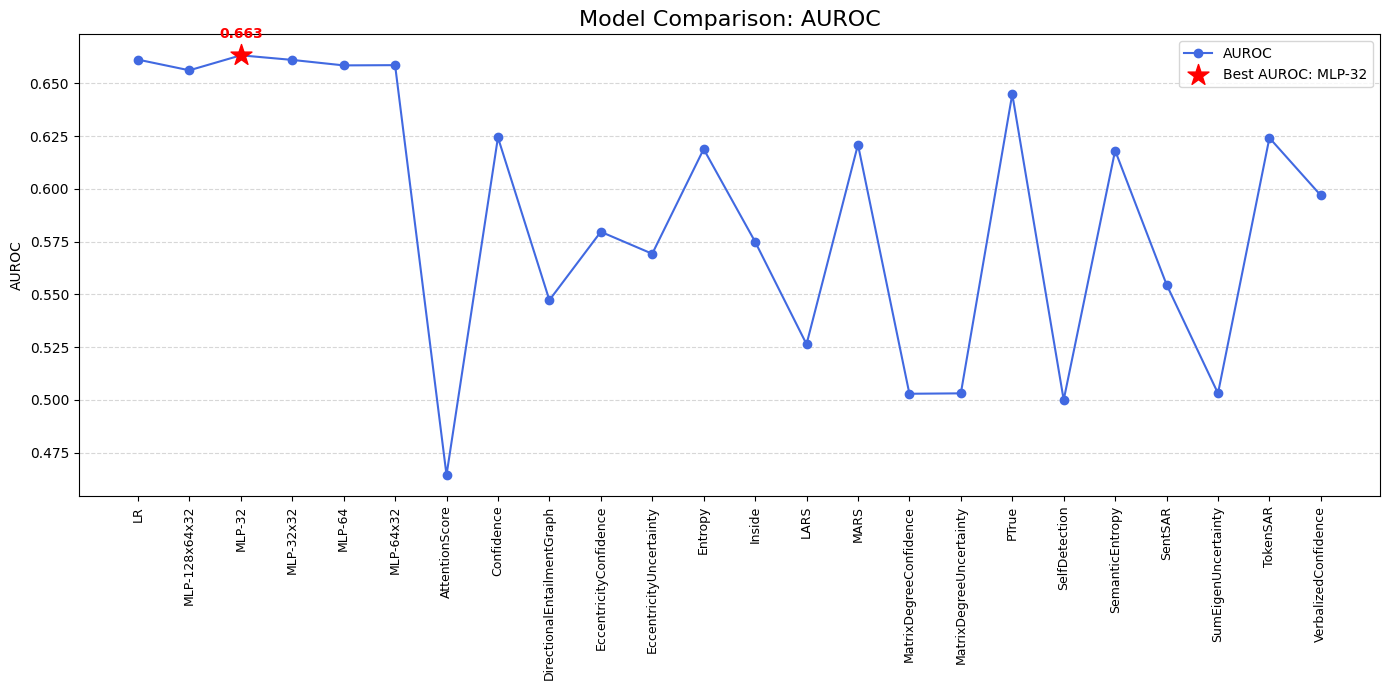

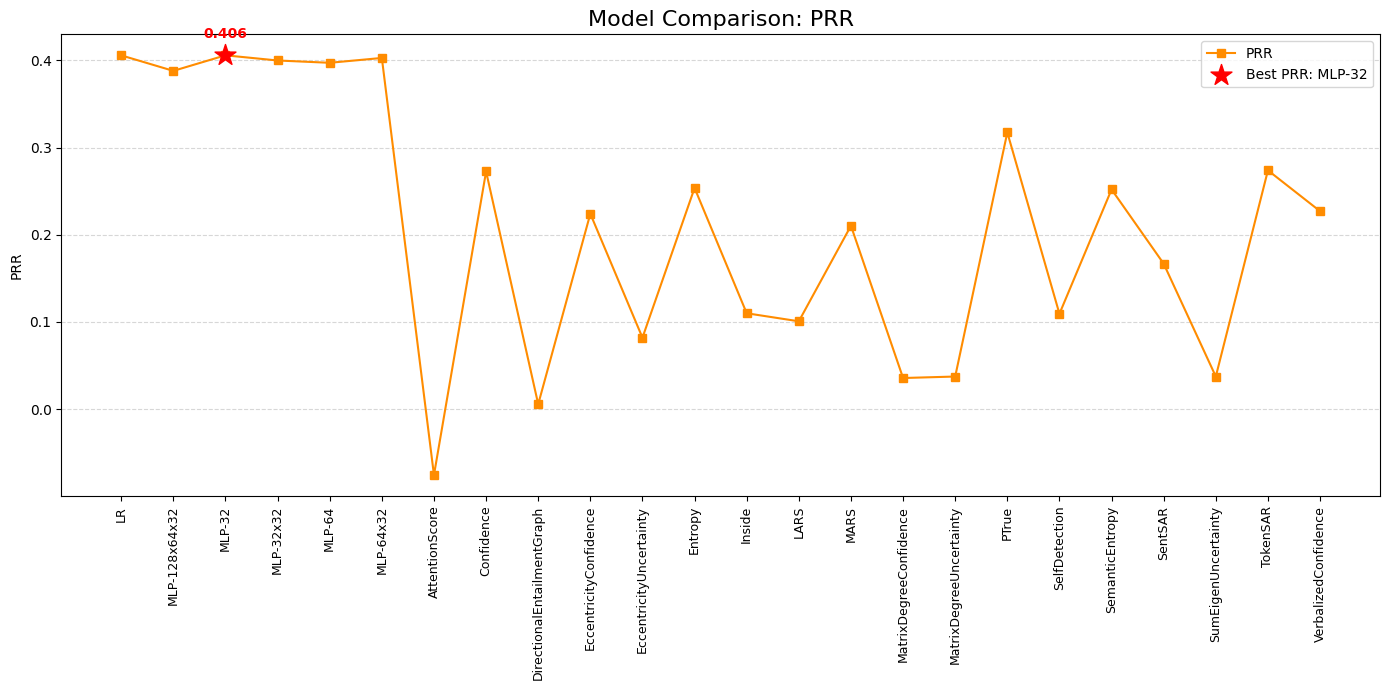

In [7]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
模型性能比较与可视化脚本。

该脚本旨在完成以下任务：
1. 加载用于训练/测试和校准的数据集。
2. 将切分后的测试数据集保存为独立的JSON文件。
3. 训练一个逻辑回归（LR）模型和多种不同架构的多层感知机（MLP）模型。
4. 计算这些模型在 AUROC 和 PRR 指标上的性能。
5. 整合一组预定义的外部基线（Uncertainty Baselines）的性能数据。
6. 将所有结果汇总到 Pandas DataFrame 中，并进行格式化处理。
7. 分别为 AUROC 和 PRR 指标生成可视化图表，清晰地展示各个模型的性能，并高亮标注每个指标的最佳模型。
"""

# ───────────────────────── 导入库 ────────────────────────────────────────
import json
import math
from typing import List, Tuple, Dict, Any, Sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score
import sklearn.isotonic as isotonic

# ───────────────────────── 全局配置 ───────────────────────────────────────
# 文件路径
TRAIN_TEST_FILE_PATH = "/home/qluai/zjs/TruthTorchLM-main/medqa/other_llm_qwen/final_simplified_results_medqa_qwen.json"
CALIBRATION_FILE_PATH = "/home/qluai/zjs/TruthTorchLM-main/medqa/other_llm_qwen/final_simplified_results_for_calibrating_medqa_qwen.json"
# 新增：定义测试数据集的保存路径
TEST_DATA_SAVE_PATH = "medqa_test_dataset.json"

# 模型和评估配置
MLP_ARCHITECTURES = [(32,), (64,), (32, 32), (64, 32), (128, 64, 32)]
METRICS_TO_CALCULATE = ["auroc", "prr"]
RANDOM_SEED = 42

# 外部基线模型的性能数据
EXTERNAL_BASELINES = {
    "Entropy": {"auroc": 0.6189044152808033, "prr": 0.2536925451552571},
    "SemanticEntropy": {"auroc": 0.6182083842516338, "prr": 0.2520014056102884},
    "MARS": {"auroc": 0.6210297008660539, "prr": 0.21037039030341234},
    "LARS": {"auroc": 0.526422613038627, "prr": 0.10078713976898536},
    "SentSAR": {"auroc": 0.5546782848945326, "prr": 0.1668422622754884},
    "TokenSAR": {"auroc": 0.6242176292439297, "prr": 0.2739017123748738},
    "Confidence": {"auroc": 0.6244301578024547, "prr": 0.27260768335917224},
    "Inside": {"auroc": 0.5749907018755646, "prr": 0.110003104391829},
    "AttentionScore": {"auroc": 0.4643961532330907, "prr": -0.07553265478409232},
    "EccentricityUncertainty": {"auroc": 0.5692843100791669, "prr": 0.08199265556187557},
    "EccentricityConfidence": {"auroc": 0.5796982094468944, "prr": 0.22412293948380943},
    "MatrixDegreeConfidence": {"auroc": 0.5029275808936826, "prr": 0.03574373938128873},
    "MatrixDegreeUncertainty": {"auroc": 0.5031188565963551, "prr": 0.03744066936270847},
    "SumEigenUncertainty": {"auroc": 0.5031294830242814, "prr": 0.03745174706977082},
    "PTrue": {"auroc": 0.6449604165559747, "prr": 0.31739060908554445},
    "VerbalizedConfidence": {"auroc": 0.5969236491153498, "prr": 0.22707433604131358},
    "SelfDetection": {"auroc": 0.5, "prr": 0.1093989226677376},
    "DirectionalEntailmentGraph": {"auroc": 0.5473035439137135, "prr": 0.005709780061758026},
}


# ───────────────────────── 辅助类与指标计算函数 ───────────────────────────
class IsotonicRegression:
    """等渗回归校准器封装。"""
    def __init__(self, y_min: float = 0.0, y_max: float = 1.0):
        self.iso = isotonic.IsotonicRegression(y_min=y_min, y_max=y_max, out_of_bounds="clip")

    def fit(self, scores: np.ndarray, labels: np.ndarray) -> None:
        """拟合模型。注意：X是分数，y是标签。"""
        self.iso.fit(scores, labels)

    def __call__(self, s: float) -> float:
        """对单个分数进行预测。"""
        return self.iso.predict([s])[0]

def normalize(arr: np.ndarray) -> np.ndarray:
    """将数组归一化到 [0, 1] 区间。"""
    a = np.asarray(arr)
    lo, hi = a.min(), a.max()
    if math.isclose(lo, hi):
        return np.zeros_like(a)
    return (a - lo) / (hi - lo)

def prediction_rejection_curve(estimator: np.ndarray, target: np.ndarray) -> float:
    """计算预测拒绝曲线下的面积 (PRR 指标的核心部分)。"""
    target = normalize(target)
    ue = np.asarray(estimator)
    order = np.argsort(ue)[::-1]
    cum_sum = np.cumsum(target[order])
    return (cum_sum / np.arange(1, len(ue) + 1)).mean()

def get_random_scores(func, metrics: np.ndarray, num_iter: int = 1000, seed: int = 42) -> float:
    """通过随机打乱顺序计算基线分数。"""
    rng = np.random.default_rng(seed)
    idx = np.arange(len(metrics))
    vals = [func(rng.permutation(idx), metrics) for _ in range(num_iter)]
    return np.mean(vals)

def calculate_metrics(metric_names: List[str], y_true: np.ndarray, y_score: np.ndarray, seed: int = 0) -> Dict[str, float]:
    """根据给定的真值和预测分数计算指定的性能指标。"""
    out = {}
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)

    if "auroc" in metric_names:
        try:
            out["auroc"] = roc_auc_score(y_true, y_score)
        except ValueError:  # 处理单类别标签的边缘情况
            out["auroc"] = 0.5

    if "prr" in metric_names:
        ue_prr = prediction_rejection_curve(y_score, y_true)
        orc_prr = prediction_rejection_curve(y_true, y_true) # Oracle
        rnd_prr = get_random_scores(prediction_rejection_curve, y_true, seed=seed) # Random
        
        denominator = orc_prr - rnd_prr
        if math.isclose(denominator, 0):
            out["prr"] = 0.0
        else:
            out["prr"] = (ue_prr - rnd_prr) / denominator
            
    return out

# ───────────────────────── 核心逻辑函数 ──────────────────────────────────
def load_data(file_path: str) -> Tuple[np.ndarray, np.ndarray]:
    """从JSON文件加载特征和标签。"""
    with open(file_path, "r", encoding="utf-8") as f:
        data = json.load(f)
    X = np.array([item["normalized_truth_values"] for item in data])
    y = np.array([item["label"] for item in data])
    return X, y

# ========================= 新增函数 =========================
def save_test_data(X_test: np.ndarray, y_test: np.ndarray, file_path: str) -> None:
    """
    将测试数据集（特征和标签）保存为JSON文件。
    其格式与输入文件保持一致，方便后续单独使用。
    """
    test_data_to_save = []
    for features, label in zip(X_test, y_test):
        # 将numpy数据类型转换为python原生类型以便JSON序列化
        item = {
            "normalized_truth_values": features.tolist(),
            "label": int(label)
        }
        test_data_to_save.append(item)
    
    with open(file_path, "w", encoding="utf-8") as f:
        # 使用 indent=4 参数使输出的JSON文件格式更美观，易于阅读
        json.dump(test_data_to_save, f, indent=4, ensure_ascii=False)
    
    print(f"\n✅ 测试数据集已成功保存至: {file_path}")
# ==========================================================

def train_and_evaluate_models(
    X_tr: np.ndarray, y_tr: np.ndarray, X_te: np.ndarray, y_te: np.ndarray
) -> List[Dict[str, Any]]:
    """训练LR和MLP模型，并评估其性能。"""
    results = []

    # --- 逻辑回归 ---
    lr = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED).fit(X_tr, y_tr)
    print("\n---------- Logistic Regression Weights ----------")
    print(f"Intercept (Bias): {lr.intercept_[0]:.4f}")
    for i, weight in enumerate(lr.coef_[0]):
        print(f"   - Weight for Feature {i+1}: {weight:.4f}")
    print("---------------------------------------------")
    
    lr_scores = lr.predict_proba(X_te)[:, 1]
    results.append({
        "model": "LR",
        **calculate_metrics(METRICS_TO_CALCULATE, y_te, lr_scores, seed=RANDOM_SEED)
    })

    # --- MLP模型 ---
    for hidden_layers in MLP_ARCHITECTURES:
        mlp = MLPClassifier(
            hidden_layer_sizes=hidden_layers, max_iter=1000, random_state=RANDOM_SEED
        ).fit(X_tr, y_tr)
        
        mlp_scores = mlp.predict_proba(X_te)[:, 1]
        model_name = "MLP-" + "x".join(map(str, hidden_layers))
        results.append({
            "model": model_name,
            **calculate_metrics(METRICS_TO_CALCULATE, y_te, mlp_scores, seed=RANDOM_SEED)
        })
        
    return results

def prepare_dataframe(model_results: List[Dict], baselines: Dict) -> pd.DataFrame:
    """整合模型结果和基线数据，创建并格式化DataFrame。"""
    all_results = model_results + [
        {"model": name, **vals} for name, vals in baselines.items()
    ]
    
    df = pd.DataFrame(all_results)
    
    # 根据模型类型定义排序键
    def get_sort_key(model_name: str) -> Tuple[int, str]:
        if model_name.startswith("LR"):
            return (0, model_name)
        if model_name.startswith("MLP"):
            return (1, model_name)
        return (2, model_name)

    df["sortkey"] = df["model"].apply(get_sort_key)
    df.sort_values("sortkey", inplace=True)
    df.drop(columns="sortkey", inplace=True)
    df.reset_index(drop=True, inplace=True)
    
    return df

def plot_metric_comparison(
    df: pd.DataFrame, 
    metric: str, 
    title: str, 
    color: str, 
    marker: str
) -> None:
    """为指定指标绘制模型性能对比图。"""
    best_idx = df[metric].idxmax()
    best_model_name = df.loc[best_idx, "model"]
    best_value = df.loc[best_idx, metric]
    
    x_ticks = np.arange(len(df))
    
    plt.figure(figsize=(14, 7))
    plt.plot(x_ticks, df[metric], marker=marker, color=color, label=metric.upper())
    
    # 高亮最佳模型
    plt.scatter(
        best_idx,
        best_value,
        marker="*",
        s=250,  # 增大星星标记
        color="red",
        zorder=5, # 确保在最上层
        label=f"Best {metric.upper()}: {best_model_name}"
    )
    
    # 在最佳模型点上标注数值
    plt.annotate(
        f"{best_value:.3f}",
        xy=(best_idx, best_value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center",
        va="bottom",
        color="red",
        fontsize=10,
        fontweight='bold'
    )
    
    plt.ylabel(metric.upper())
    plt.title(title, fontsize=16)
    plt.grid(axis='y', alpha=0.5, linestyle='--')
    plt.xticks(x_ticks, df["model"], rotation=90, fontsize=9)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ───────────────────────── 主执行流程 ─────────────────────────────────────
def main() -> None:
    """脚本主入口和执行流程。"""
    # 1. 加载并切分数据
    X, y = load_data(TRAIN_TEST_FILE_PATH)
    X_tr, X_te, y_tr, y_te = train_test_split(
        X, y, test_size=0.3, random_state=RANDOM_SEED, stratify=y
    )

    # 2. 【新增功能】保存测试数据集
    save_test_data(X_te, y_te, TEST_DATA_SAVE_PATH)

    # 3. 训练模型并获取结果
    model_results = train_and_evaluate_models(X_tr, y_tr, X_te, y_te)
    
    # 4. 准备最终的DataFrame
    df_final = prepare_dataframe(model_results, EXTERNAL_BASELINES)
    
    # 5. 打印结果摘要
    print("\n========= Summary (AUROC / PRR) - Uncalibrated & Baselines =========")
    print(df_final.round(4).to_string(index=False))
    
    best_auroc_model = df_final.loc[df_final["auroc"].idxmax()]
    best_prr_model = df_final.loc[df_final["prr"].idxmax()]
    print(
        f"\n👑 Best AUROC : {best_auroc_model['model']} ({best_auroc_model['auroc']:.4f})"
    )
    print(
        f"👑 Best PRR   : {best_prr_model['model']} ({best_prr_model['prr']:.4f})"
    )

    # 6. 可视化结果
    plot_metric_comparison(
        df=df_final, 
        metric="auroc", 
        title="Model Comparison: AUROC", 
        color="royalblue", 
        marker="o"
    )
    plot_metric_comparison(
        df=df_final, 
        metric="prr", 
        title="Model Comparison: PRR", 
        color="darkorange", 
        marker="s"
    )

if __name__ == "__main__":
    main()

In [ ]:
在medqa上的泛化实验 ，数据路径： /home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/medqa_test_dataset.json

In [ ]:
泛化结果

In [ ]:
MedQA基线数据

In [ ]:
Entropy: {'auroc': 0.6189044152808033, 'prr': 0.2536925451552571}
SemanticEntropy: {'auroc': 0.6182083842516338, 'prr': 0.2520014056102884}
MARS: {'auroc': 0.6210297008660539, 'prr': 0.21037039030341234}
LARS: {'auroc': 0.526422613038627, 'prr': 0.10078713976898536}
SentSAR: {'auroc': 0.5546782848945326, 'prr': 0.1668422622754884}
TokenSAR: {'auroc': 0.6242176292439297, 'prr': 0.2739017123748738}
Confidence: {'auroc': 0.6244301578024547, 'prr': 0.27260768335917224}
Inside: {'auroc': 0.5749907018755646, 'prr': 0.110003104391829}
AttentionScore: {'auroc': 0.4643961532330907, 'prr': -0.07553265478409232}
EccentricityUncertainty: {'auroc': 0.5692843100791669, 'prr': 0.08199265556187557}
EccentricityConfidence: {'auroc': 0.5796982094468944, 'prr': 0.22412293948380943}
MatrixDegreeConfidence: {'auroc': 0.5029275808936826, 'prr': 0.03574373938128873}
MatrixDegreeUncertainty: {'auroc': 0.5031188565963551, 'prr': 0.03744066936270847}
SumEigenUncertainty: {'auroc': 0.5031294830242814, 'prr': 0.03745174706977082}
PTrue: {'auroc': 0.6449604165559747, 'prr': 0.31739060908554445}
VerbalizedConfidence: {'auroc': 0.5969236491153498, 'prr': 0.22707433604131358}
SelfDetection: {'auroc': 0.5, 'prr': 0.1093989226677376}
DirectionalEntailmentGraph: {'auroc': 0.5473035439137135, 'prr': 0.005709780061758026}


========= MedMCQA PRR (mean ± std) =========
       model prr_mean prr_std
          LR   0.4784  0.0010
       MLP32   0.4715  0.0033
       MLP64   0.4703  0.0026
    MLP32x32   0.4646  0.0157
    MLP64x32   0.4632  0.0024
MLP128x64x32   0.4158  0.0380

🌱 Best single → MLP32x32  (seed=123,  PRR=0.4820)
📊 Best mean   → LR (PRR_mean=0.4784 ± 0.0010)


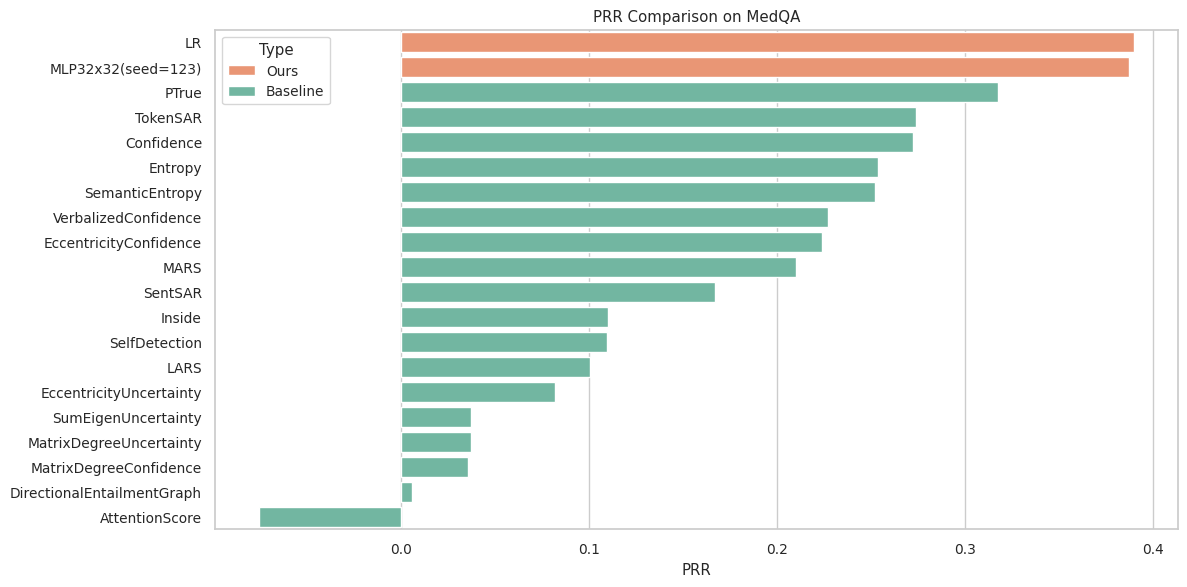

[PRR] 1st: LR (0.3898)  |  2nd: MLP32x32(seed=123) (0.3873)  |  Δ=0.0025


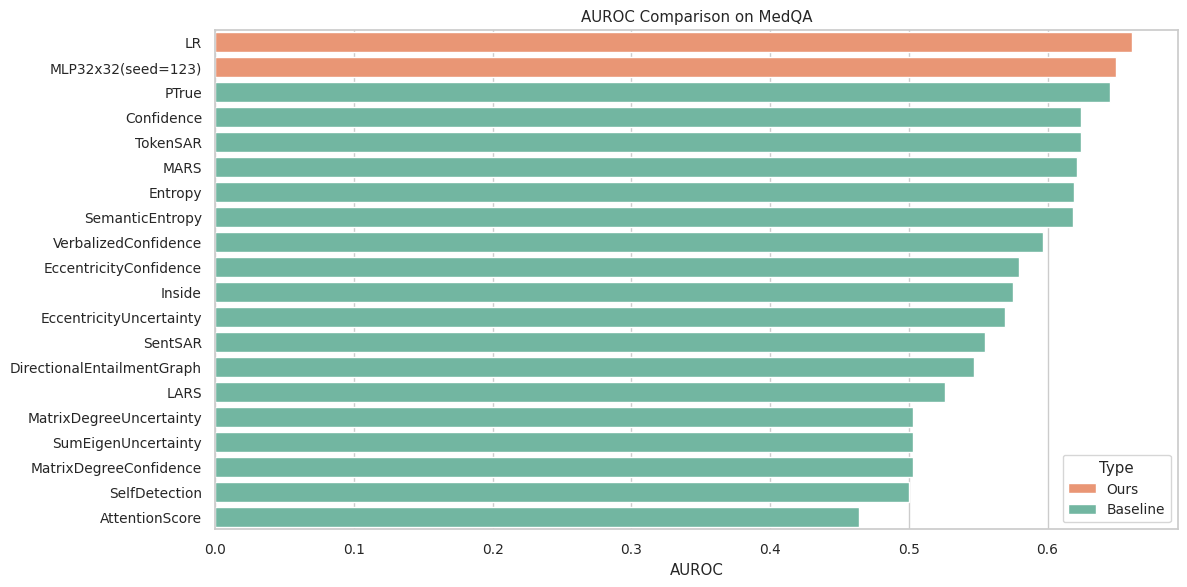

[AUROC] 1st: LR (0.6607)  |  2nd: MLP32x32(seed=123) (0.6497)  |  Δ=0.0111


In [8]:
# -*- coding: utf-8 -*-
"""
Multi‑seed model selection on MedMCQA ➜ generalization to MedQA
==============================================================
Workflow
--------
1. **Training / Selection (MedMCQA)**
   • Train LR + several MLP architectures under a list of random seeds.
   • For each architecture record PRR for every seed → compute mean ± std.
   • Identify:
       ─ *Best‑Single*  = highest PRR over **all** (model, seed) pairs.
       ─ *Best‑Mean*    = architecture with highest **mean PRR**.
2. **Generalization (MedQA)**
   • Re‑instantiate the above two models:
       ─ Best‑Single uses the exact seed that gave the peak PRR.
       ─ Best‑Mean  retrains with a fixed seed (42) for stability.
   • Evaluate both on MedQA (AUROC & PRR).
3. **Visualization** – Bar charts (PRR & AUROC) comparing:
       Best‑Single | Best‑Mean | External baselines.
   Prints top‑2 gaps for quick inspection.

Note: External baselines kept identical to user‑provided numbers (assumed MedQA).
"""

# ───────────────────────── Imports & Global Config ─────────────────────────
import json, math, warnings
from pathlib import Path
from typing import Dict, Any, List, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning)

# ---------- user paths ----------
TRAIN_TEST_FILE_PATH = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json"  # MedMCQA (train/val/test)
MEDQA_TEST_PATH      = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/medqa_test_dataset.json"   # MedQA (held‑out test)

# ---------- model space ----------
MLP_SPACE: Sequence[tuple] = [(32,), (64,), (32, 32), (64, 32), (128, 64, 32)]
RANDOM_SEEDS: Sequence[int] = [42, 7, 99, 123, 2025]
SPLIT_SEED: int = 42   # keep MedMCQA train/test split fixed

# ---------- external baselines (MedQA) ----------
BASELINES: Dict[str, Dict[str, float]] = {
    "Entropy":                   {"auroc": 0.6189,  "prr": 0.2537},
    "SemanticEntropy":           {"auroc": 0.6182,  "prr": 0.2520},
    "MARS":                      {"auroc": 0.6210,  "prr": 0.2104},
    "LARS":                      {"auroc": 0.5264,  "prr": 0.1008},
    "SentSAR":                   {"auroc": 0.5547,  "prr": 0.1668},
    "TokenSAR":                  {"auroc": 0.6242,  "prr": 0.2739},
    "Confidence":                {"auroc": 0.6244,  "prr": 0.2726},
    "Inside":                    {"auroc": 0.5750,  "prr": 0.1100},
    "AttentionScore":            {"auroc": 0.4644,  "prr": -0.0755},
    "EccentricityUncertainty":   {"auroc": 0.5693,  "prr": 0.0820},
    "EccentricityConfidence":    {"auroc": 0.5797,  "prr": 0.2241},
    "MatrixDegreeConfidence":    {"auroc": 0.5029,  "prr": 0.0357},
    "MatrixDegreeUncertainty":   {"auroc": 0.5031,  "prr": 0.0374},
    "SumEigenUncertainty":       {"auroc": 0.5031,  "prr": 0.0375},
    "PTrue":                     {"auroc": 0.6450,  "prr": 0.3174},
    "VerbalizedConfidence":      {"auroc": 0.5969,  "prr": 0.2271},
    "SelfDetection":             {"auroc": 0.5000,  "prr": 0.1094},
    "DirectionalEntailmentGraph":{"auroc": 0.5473,  "prr": 0.0057},
}




# ───────────────────────── Metric helpers ─────────────────────────────────

def _normalize(a: np.ndarray) -> np.ndarray:
    lo, hi = a.min(), a.max()
    return np.zeros_like(a) if math.isclose(lo, hi) else (a - lo) / (hi - lo)

def _prediction_rejection_curve(est, tgt):
    tgt = _normalize(tgt)
    order = np.argsort(est)[::-1]
    cum = np.cumsum(tgt[order])
    return (cum / np.arange(1, len(est) + 1)).mean()

def _random_prr(tgt, iters=1000, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(tgt))
    vals = [_prediction_rejection_curve(rng.permutation(idx), tgt) for _ in range(iters)]
    return float(np.mean(vals))

def prr_score(y_true: np.ndarray, y_score: np.ndarray, seed=0):
    ue = _prediction_rejection_curve(y_score, y_true)
    orc = _prediction_rejection_curve(y_true, y_true)
    rnd = _random_prr(y_true, seed=seed)
    return 0.0 if math.isclose(orc, rnd) else (ue - rnd) / (orc - rnd)

def auroc_score_safe(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except ValueError:
        return 0.5

# ───────────────────────── Data loading ─────────────────────────────────

def load_dataset(path: str) -> Tuple[np.ndarray, np.ndarray]:
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)
    X = np.array([it["normalized_truth_values"] for it in d])
    y = np.array([it["label"] for it in d])
    return X, y

# ───────────────────────── Training & selection (MedMCQA) ──────────────

def train_multi_seed(X_tr, y_tr, X_te, y_te) -> Tuple[Dict[str, List[float]], Dict[str, Any], Dict[str, Any]]:
    prr_table: Dict[str, List[float]] = {}
    best_single = {"model": None, "seed": None, "prr": -float("inf"), "model_obj": None}

    for seed in RANDOM_SEEDS:
        # LR
        lr = LogisticRegression(max_iter=1000, random_state=seed).fit(X_tr, y_tr)
        prr_lr = prr_score(y_te, lr.predict_proba(X_te)[:,1], seed)
        prr_table.setdefault("LR", []).append(prr_lr)
        if prr_lr > best_single["prr"]:
            best_single.update({"model": "LR", "seed": seed, "prr": prr_lr, "model_obj": lr})

        # MLPs
        for hid in MLP_SPACE:
            name = "MLP" + "x".join(map(str, hid))
            mlp = MLPClassifier(hidden_layer_sizes=hid, max_iter=1000, random_state=seed).fit(X_tr, y_tr)
            prr_val = prr_score(y_te, mlp.predict_proba(X_te)[:,1], seed)
            prr_table.setdefault(name, []).append(prr_val)
            if prr_val > best_single["prr"]:
                best_single.update({"model": name, "seed": seed, "prr": prr_val, "model_obj": mlp})

    # compute mean/std
    df = pd.DataFrame([{"model": m, "prr_mean": np.mean(v), "prr_std": np.std(v, ddof=0)} for m,v in prr_table.items()])
    best_mean_row = df.loc[df["prr_mean"].idxmax()].to_dict()

    # re‑train best‑mean architecture with fixed seed 42 for generalization
    if best_mean_row["model"] == "LR":
        bm_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr, y_tr)
    else:
        arch = tuple(int(x) for x in best_mean_row["model"].replace("MLP", "").split("x"))
        bm_model = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42).fit(X_tr, y_tr)
    best_mean_row.update({"model_obj": bm_model})

    print("\n========= MedMCQA PRR (mean ± std) =========")
    print(df.to_string(index=False, formatters={"prr_mean":lambda x:f"{x:.4f}", "prr_std":lambda x:f"{x:.4f}"}))
    print(f"\n🌱 Best single → {best_single['model']}  (seed={best_single['seed']},  PRR={best_single['prr']:.4f})")
    print(f"📊 Best mean   → {best_mean_row['model']} (PRR_mean={best_mean_row['prr_mean']:.4f} ± {best_mean_row['prr_std']:.4f})")

    return prr_table, best_single, best_mean_row

# ───────────────────────── Evaluation on MedQA ─────────────────────────

def evaluate_model(model, X_te, y_te):
    prob = model.predict_proba(X_te)[:,1]
    return {
        "auroc": auroc_score_safe(y_te, prob),
        "prr":   prr_score(y_te, prob),
    }

# ───────────────────────── Visualization ───────────────────────────────

def visualize_generalization(results_dict: Dict[str, Dict[str,float]]):
    sns.set(style="whitegrid", font_scale=0.9)
    palette = {"Baseline": "#66c2a5", "Ours": "#fc8d62"}

    df = pd.DataFrame.from_dict(results_dict, orient="index")
    df["method"] = df.index
    df["type"]   = df["method"].apply(lambda m: "Baseline" if m in BASELINES else "Ours")

    # PRR plot
    plt.figure(figsize=(12,6))
    df_prr = df.sort_values("prr", ascending=False)
    sns.barplot(data=df_prr, x="prr", y="method", hue="type", palette=palette)
    plt.title("PRR Comparison on MedQA")
    plt.xlabel("PRR")
    plt.ylabel("")
    plt.legend(title="Type")
    plt.tight_layout()
    plt.show()

    top2 = df_prr[["method","type","prr"]].head(2).reset_index(drop=True)
    print(f"[PRR] 1st: {top2.loc[0,'method']} ({top2.loc[0,'prr']:.4f})  |  2nd: {top2.loc[1,'method']} ({top2.loc[1,'prr']:.4f})  |  Δ={top2.loc[0,'prr']-top2.loc[1,'prr']:.4f}")

    # AUROC plot
    plt.figure(figsize=(12,6))
    df_auc = df.sort_values("auroc", ascending=False)
    sns.barplot(data=df_auc, x="auroc", y="method", hue="type", palette=palette)
    plt.title("AUROC Comparison on MedQA")
    plt.xlabel("AUROC")
    plt.ylabel("")
    plt.legend(title="Type")
    plt.tight_layout()
    plt.show()

    top2a = df_auc[["method","type","auroc"]].head(2).reset_index(drop=True)
    print(f"[AUROC] 1st: {top2a.loc[0,'method']} ({top2a.loc[0,'auroc']:.4f})  |  2nd: {top2a.loc[1,'method']} ({top2a.loc[1,'auroc']:.4f})  |  Δ={top2a.loc[0,'auroc']-top2a.loc[1,'auroc']:.4f}")

# ───────────────────────── Main -------------------------------------------------------------------------

def main():
    # 1. Load datasets
    X_all, y_all = load_dataset(TRAIN_TEST_FILE_PATH)
    X_medqa, y_medqa = load_dataset(MEDQA_TEST_PATH)

    # 2. Split MedMCQA for selection
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=SPLIT_SEED, stratify=y_all)

    # 3. Train, select models
    _, best_single, best_mean = train_multi_seed(X_tr, y_tr, X_te, y_te)

    # 4. Evaluate on MedQA
    gen_results: Dict[str, Dict[str,float]] = {}
    # ours
    gen_results[f"{best_single['model']}(seed={best_single['seed']})"] = evaluate_model(best_single["model_obj"], X_medqa, y_medqa)
    gen_results[best_mean["model"]] = evaluate_model(best_mean["model_obj"], X_medqa, y_medqa)
    # baselines
    for b, v in BASELINES.items():
        gen_results[b] = v

    # 5. Visualize & print gaps
    visualize_generalization(gen_results)


if __name__ == "__main__":
    main()



========= MedMCQA PRR (mean ± std) =========
       model prr_mean prr_std
          LR   0.4784  0.0010
       MLP32   0.4715  0.0033
       MLP64   0.4703  0.0026
    MLP32x32   0.4646  0.0157
    MLP64x32   0.4632  0.0024
MLP128x64x32   0.4158  0.0380

🌱 Best single → MLP32x32  (seed=123,  PRR=0.4820)
📊 Best mean   → LR (PRR_mean=0.4784 ± 0.0010)

✨ Generating beautiful visualizations with your color palette...


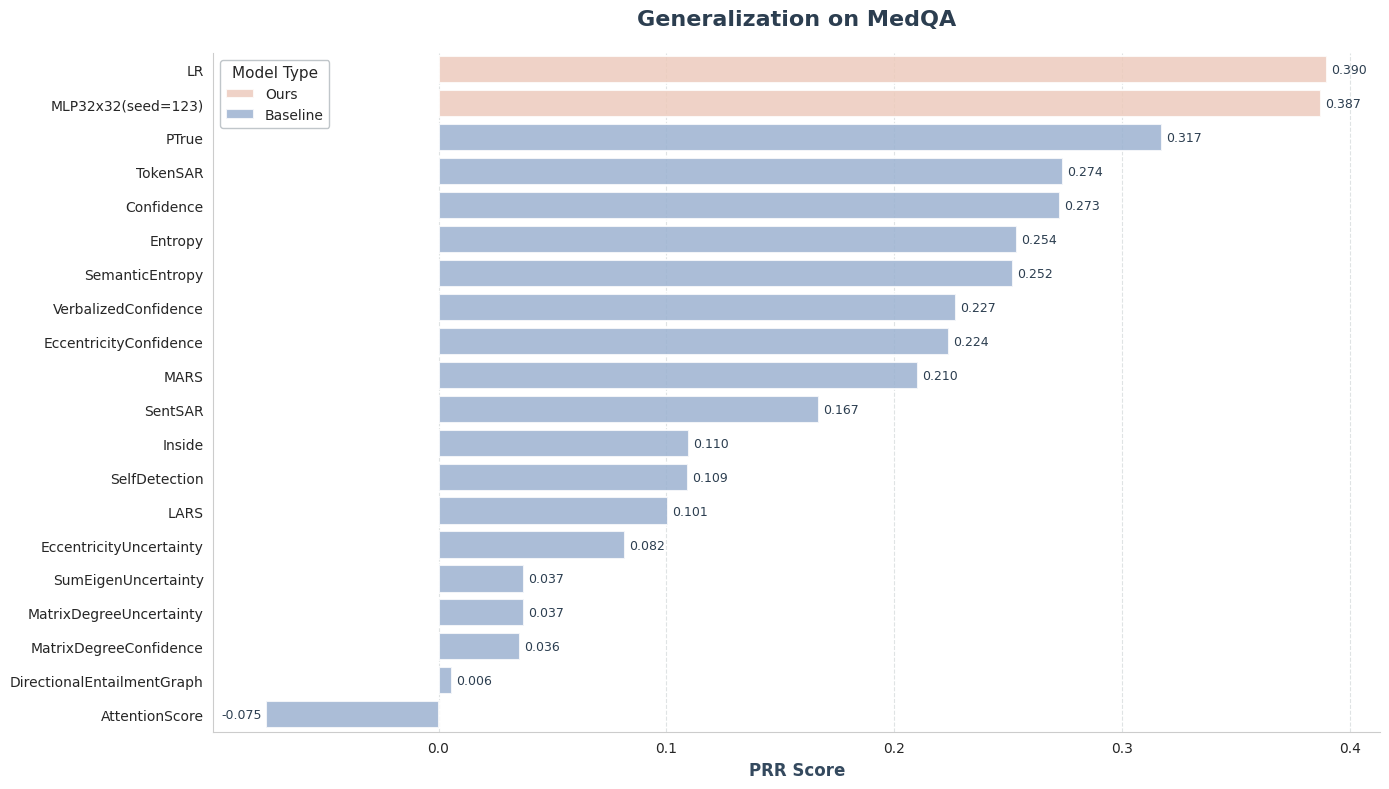


🏆 [PRR Rankings]
   🥇 1st: LR (0.3898)
   🥈 2nd: MLP32x32(seed=123) (0.3873)
   📊 Gap: Δ = 0.0025


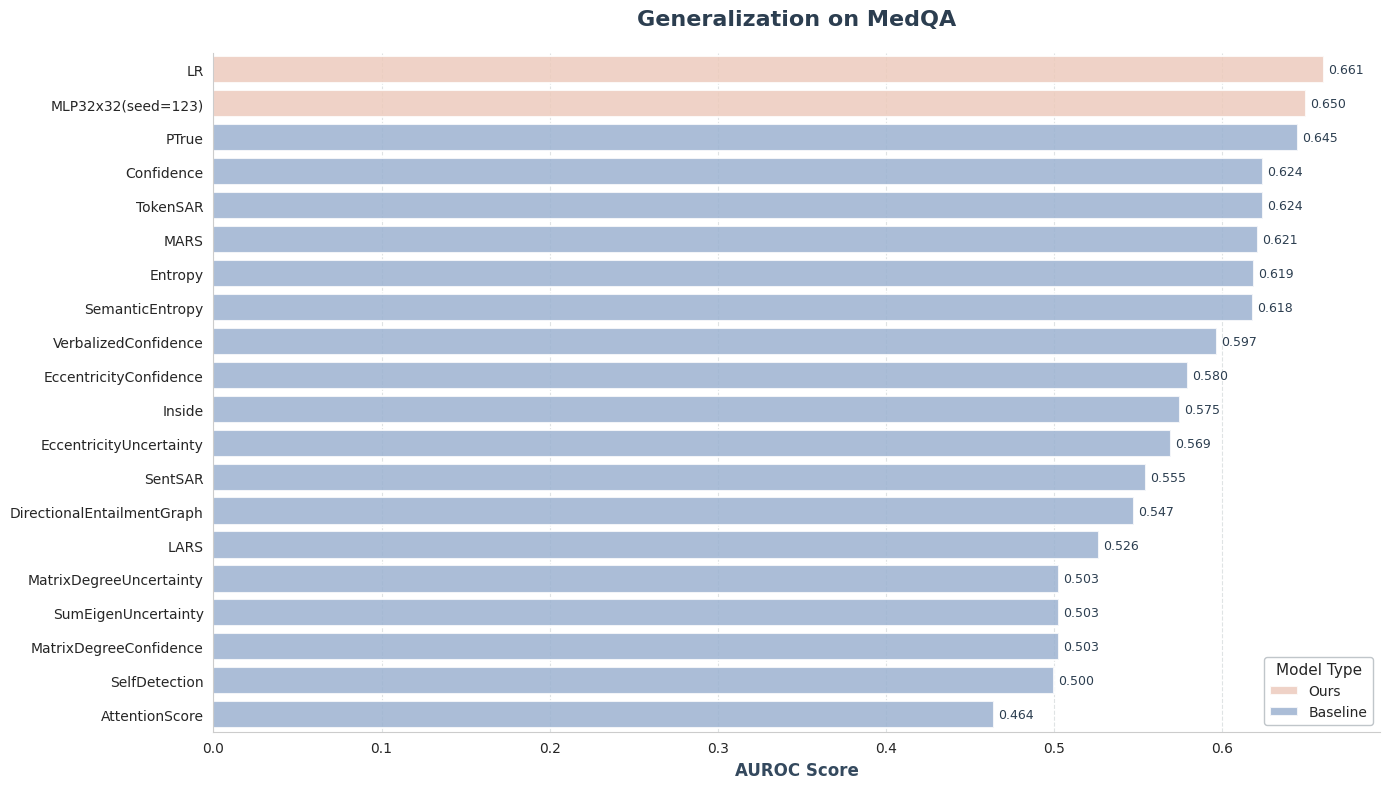


🏆 [AUROC Rankings]
   🥇 1st: LR (0.6607)
   🥈 2nd: MLP32x32(seed=123) (0.6497)
   📊 Gap: Δ = 0.0111


In [1]:
# -*- coding: utf-8 -*-
"""
Multi‑seed model selection on MedMCQA ➜ generalization to MedQA
==============================================================
✨ (Visualization Enhanced for Qwen) ✨
Workflow
--------
1. **Training / Selection (MedMCQA)**
    • Train LR + several MLP architectures under a list of random seeds.
    • For each architecture record PRR for every seed → compute mean ± std.
    • Identify:
        ─ *Best‑Single* = highest PRR over **all** (model, seed) pairs.
        ─ *Best‑Mean* = architecture with highest **mean PRR**.
2. **Generalization (MedQA)**
    • Re‑instantiate the above two models:
        ─ Best‑Single uses the exact seed that gave the peak PRR.
        ─ Best‑Mean  retrains with a fixed seed (42) for stability.
    • Evaluate both on MedQA (AUROC & PRR).
3. **Visualization** – Bar charts (PRR & AUROC) comparing:
        Best‑Single | Best‑Mean | External baselines.
    Prints top‑2 gaps for quick inspection.

Note: External baselines kept identical to user‑provided numbers (assumed MedQA).
"""

# ───────────────────────── Imports & Global Config ─────────────────────────
import json, math, warnings
from pathlib import Path
from typing import Dict, Any, List, Sequence, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning)

# ---------- user paths (Qwen version) ----------
TRAIN_TEST_FILE_PATH = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/final_simplified_results_qwen_1.json"  # MedMCQA (train/val/test)
MEDQA_TEST_PATH      = "/home/qluai/zjs/TruthTorchLM-main/medmcqa/other_llm_qwen/medqa_test_dataset.json"  # MedQA (held‑out test)

# ---------- model space ----------
MLP_SPACE: Sequence[tuple] = [(32,), (64,), (32, 32), (64, 32), (128, 64, 32)]
RANDOM_SEEDS: Sequence[int] = [42, 7, 99, 123, 2025]
SPLIT_SEED: int = 42  # keep MedMCQA train/test split fixed

# ---------- external baselines (Qwen version, MedQA) ----------
BASELINES: Dict[str, Dict[str, float]] = {
    "Entropy": {"auroc": 0.6189, "prr": 0.2537},
    "SemanticEntropy": {"auroc": 0.6182, "prr": 0.2520},
    "MARS": {"auroc": 0.6210, "prr": 0.2104},
    "LARS": {"auroc": 0.5264, "prr": 0.1008},
    "SentSAR": {"auroc": 0.5547, "prr": 0.1668},
    "TokenSAR": {"auroc": 0.6242, "prr": 0.2739},
    "Confidence": {"auroc": 0.6244, "prr": 0.2726},
    "Inside": {"auroc": 0.5750, "prr": 0.1100},
    "AttentionScore": {"auroc": 0.4644, "prr": -0.0755},
    "EccentricityUncertainty": {"auroc": 0.5693, "prr": 0.0820},
    "EccentricityConfidence": {"auroc": 0.5797, "prr": 0.2241},
    "MatrixDegreeConfidence": {"auroc": 0.5029, "prr": 0.0357},
    "MatrixDegreeUncertainty": {"auroc": 0.5031, "prr": 0.0374},
    "SumEigenUncertainty": {"auroc": 0.5031, "prr": 0.0375},
    "PTrue": {"auroc": 0.6450, "prr": 0.3174},
    "VerbalizedConfidence": {"auroc": 0.5969, "prr": 0.2271},
    "SelfDetection": {"auroc": 0.5000, "prr": 0.1094},
    "DirectionalEntailmentGraph": {"auroc": 0.5473, "prr": 0.0057},
}


# ───────────────────────── Metric helpers ─────────────────────────────────

def _normalize(a: np.ndarray) -> np.ndarray:
    lo, hi = a.min(), a.max()
    return np.zeros_like(a) if math.isclose(lo, hi) else (a - lo) / (hi - lo)

def _prediction_rejection_curve(est, tgt):
    tgt = _normalize(tgt)
    order = np.argsort(est)[::-1]
    cum = np.cumsum(tgt[order])
    return (cum / np.arange(1, len(est) + 1)).mean()

def _random_prr(tgt, iters=1000, seed=0):
    rng = np.random.default_rng(seed)
    idx = np.arange(len(tgt))
    vals = [_prediction_rejection_curve(rng.permutation(idx), tgt) for _ in range(iters)]
    return float(np.mean(vals))

def prr_score(y_true: np.ndarray, y_score: np.ndarray, seed=0):
    ue = _prediction_rejection_curve(y_score, y_true)
    orc = _prediction_rejection_curve(y_true, y_true)
    rnd = _random_prr(y_true, seed=seed)
    return 0.0 if math.isclose(orc, rnd) else (ue - rnd) / (orc - rnd)

def auroc_score_safe(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except ValueError:
        return 0.5

# ───────────────────────── Data loading ─────────────────────────────────

def load_dataset(path: str) -> Tuple[np.ndarray, np.ndarray]:
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)
    X = np.array([it["normalized_truth_values"] for it in d])
    y = np.array([it["label"] for it in d])
    return X, y

# ───────────────────────── Training & selection (MedMCQA) ──────────────

def train_multi_seed(X_tr, y_tr, X_te, y_te) -> Tuple[Dict[str, List[float]], Dict[str, Any], Dict[str, Any]]:
    prr_table: Dict[str, List[float]] = {}
    best_single = {"model": None, "seed": None, "prr": -float("inf"), "model_obj": None}

    for seed in RANDOM_SEEDS:
        # LR
        lr = LogisticRegression(max_iter=1000, random_state=seed).fit(X_tr, y_tr)
        prr_lr = prr_score(y_te, lr.predict_proba(X_te)[:,1], seed)
        prr_table.setdefault("LR", []).append(prr_lr)
        if prr_lr > best_single["prr"]:
            best_single.update({"model": "LR", "seed": seed, "prr": prr_lr, "model_obj": lr})

        # MLPs
        for hid in MLP_SPACE:
            name = "MLP" + "x".join(map(str, hid))
            mlp = MLPClassifier(hidden_layer_sizes=hid, max_iter=1000, random_state=seed).fit(X_tr, y_tr)
            prr_val = prr_score(y_te, mlp.predict_proba(X_te)[:,1], seed)
            prr_table.setdefault(name, []).append(prr_val)
            if prr_val > best_single["prr"]:
                best_single.update({"model": name, "seed": seed, "prr": prr_val, "model_obj": mlp})

    # compute mean/std
    df = pd.DataFrame([{"model": m, "prr_mean": np.mean(v), "prr_std": np.std(v, ddof=0)} for m,v in prr_table.items()])
    best_mean_row = df.loc[df["prr_mean"].idxmax()].to_dict()

    # re‑train best‑mean architecture with fixed seed 42 for generalization
    if best_mean_row["model"] == "LR":
        bm_model = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr, y_tr)
    else:
        arch = tuple(int(x) for x in best_mean_row["model"].replace("MLP", "").split("x"))
        bm_model = MLPClassifier(hidden_layer_sizes=arch, max_iter=1000, random_state=42).fit(X_tr, y_tr)
    best_mean_row.update({"model_obj": bm_model})

    print("\n========= MedMCQA PRR (mean ± std) =========")
    print(df.to_string(index=False, formatters={"prr_mean":lambda x:f"{x:.4f}", "prr_std":lambda x:f"{x:.4f}"}))
    print(f"\n🌱 Best single → {best_single['model']}  (seed={best_single['seed']},  PRR={best_single['prr']:.4f})")
    print(f"📊 Best mean   → {best_mean_row['model']} (PRR_mean={best_mean_row['prr_mean']:.4f} ± {best_mean_row['prr_std']:.4f})")

    return prr_table, best_single, best_mean_row

# ───────────────────────── Evaluation on MedQA ─────────────────────────

def evaluate_model(model, X_te, y_te):
    prob = model.predict_proba(X_te)[:,1]
    return {
        "auroc": auroc_score_safe(y_te, prob),
        "prr":   prr_score(y_te, prob),
    }

# ───────────────────────── Visualization (IMPROVED!) ───────────────────────────────

def visualize_generalization(results_dict: Dict[str, Dict[str,float]]):
    """
    ✨ Enhanced visualization with beautiful color palette
    Colors from your selection: #90a4c5, #93b0da, #bfd8ec, #dbdcee, #f5c8b5
    """
    # Enhanced styling
    sns.set_style("whitegrid", {'grid.linestyle': '--', 'grid.alpha': 0.3})
    plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
    plt.rcParams['font.size'] = 10
    
    # Your beautiful color palette (using main colors for Baseline vs Ours)
    palette = {
        "Baseline": "#93b0da",  # Soft blue for baselines
        "Ours": "#f5c8b5"       # Warm peach for our models
    }
    
    df = pd.DataFrame.from_dict(results_dict, orient="index")
    df["method"] = df.index
    # 这里的 BASELINES 会正确地使用您在脚本顶部定义的全局变量
    df["type"] = df["method"].apply(lambda m: "Baseline" if m in BASELINES else "Ours")

    # ========== PRR plot with enhanced styling ==========
    fig, ax = plt.subplots(figsize=(14, 8))
    df_prr = df.sort_values("prr", ascending=False)
    
    bars = sns.barplot(
        data=df_prr, 
        x="prr", 
        y="method", 
        hue="type", 
        palette=palette,
        ax=ax,
        edgecolor='white',
        linewidth=1.5,
        alpha=0.85
    )
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9, color='#2c3e50')
    
    ax.set_title("Generalization on MedQA", 
                 fontsize=16, fontweight='bold', pad=20, color='#2c3e50')
    ax.set_xlabel("PRR Score", 
                  fontsize=12, fontweight='semibold', color='#34495e')
    ax.set_ylabel("")
    ax.legend(title="Model Type", title_fontsize=11, fontsize=10, 
              framealpha=0.95, edgecolor='#bdc3c7')
    ax.grid(axis='x', alpha=0.3, linestyle='--', color='#95a5a6')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    # (!!) 注意：保存路径已更新，以反映 "qwen"
    plt.savefig('/home/qluai/zjs/TruthTorchLM-main/图片/泛化实验/qwen_medmcqa_prr_generalization.png', 
                dpi=1200, bbox_inches='tight', facecolor='white')
    plt.savefig('/home/qluai/zjs/TruthTorchLM-main/图片/PDF/generalization/qwen_medmcqa_prr_generalization.pdf', dpi=300, bbox_inches='tight', format='pdf')
    plt.show()

    top2 = df_prr[["method","type","prr"]].head(2).reset_index(drop=True)
    print(f"\n🏆 [PRR Rankings]")
    print(f"   🥇 1st: {top2.loc[0,'method']} ({top2.loc[0,'prr']:.4f})")
    print(f"   🥈 2nd: {top2.loc[1,'method']} ({top2.loc[1,'prr']:.4f})")
    print(f"   📊 Gap: Δ = {top2.loc[0,'prr']-top2.loc[1,'prr']:.4f}")

    # ========== AUROC plot with enhanced styling ==========
    fig, ax = plt.subplots(figsize=(14, 8))
    df_auc = df.sort_values("auroc", ascending=False)
    
    bars = sns.barplot(
        data=df_auc, 
        x="auroc", 
        y="method", 
        hue="type", 
        palette=palette,
        ax=ax,
        edgecolor='white',
        linewidth=1.5,
        alpha=0.85
    )
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9, color='#2c3e50')
    
    ax.set_title("Generalization on MedQA", 
                 fontsize=16, fontweight='bold', pad=20, color='#2c3e50')
    ax.set_xlabel("AUROC Score", 
                  fontsize=12, fontweight='semibold', color='#34495e')
    ax.set_ylabel("")
    ax.legend(title="Model Type", title_fontsize=11, fontsize=10, 
              framealpha=0.95, edgecolor='#bdc3c7')
    ax.grid(axis='x', alpha=0.3, linestyle='--', color='#95a5a6')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    plt.tight_layout()
    # (!!) 注意：保存路径已更新，以反映 "qwen"
    plt.savefig('/home/qluai/zjs/TruthTorchLM-main/图片/泛化实验/qwen_medmcqa_auroc_generalization.png', 
                dpi=1200, bbox_inches='tight', facecolor='white')
    plt.savefig('/home/qluai/zjs/TruthTorchLM-main/图片/PDF/generalization/qwen_medmcqa_AUROC_generalization.pdf', dpi=300, bbox_inches='tight', format='pdf')
    plt.show()

    top2a = df_auc[["method","type","auroc"]].head(2).reset_index(drop=True)
    print(f"\n🏆 [AUROC Rankings]")
    print(f"   🥇 1st: {top2a.loc[0,'method']} ({top2a.loc[0,'auroc']:.4f})")
    print(f"   🥈 2nd: {top2a.loc[1,'method']} ({top2a.loc[1,'auroc']:.4f})")
    print(f"   📊 Gap: Δ = {top2a.loc[0,'auroc']-top2a.loc[1,'auroc']:.4f}")

# ───────────────────────── Main -------------------------------------------------------------------------

def main():
    # 1. Load datasets
    X_all, y_all = load_dataset(TRAIN_TEST_FILE_PATH)
    X_medqa, y_medqa = load_dataset(MEDQA_TEST_PATH)

    # 2. Split MedMCQA for selection
    X_tr, X_te, y_tr, y_te = train_test_split(X_all, y_all, test_size=0.3, random_state=SPLIT_SEED, stratify=y_all)

    # 3. Train, select models
    _, best_single, best_mean = train_multi_seed(X_tr, y_tr, X_te, y_te)

    # 4. Evaluate on MedQA
    gen_results: Dict[str, Dict[str,float]] = {}
    # ours
    gen_results[f"{best_single['model']}(seed={best_single['seed']})"] = evaluate_model(best_single["model_obj"], X_medqa, y_medqa)
    gen_results[best_mean["model"]] = evaluate_model(best_mean["model_obj"], X_medqa, y_medqa)
    # baselines
    for b, v in BASELINES.items():
        gen_results[b] = v

    # 5. Visualize & print gaps (with enhanced print output)
    print("\n" + "="*60)
    print("✨ Generating beautiful visualizations with your color palette...")
    print("="*60)
    visualize_generalization(gen_results)


if __name__ == "__main__":
    main()